### Importing Packages

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm 

import scipy
from scipy.optimize import linear_sum_assignment

import copy

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from functools import partial

from sklearn.cluster import KMeans

import string

import torch.nn.functional as F

### Seed

In [2]:
SEED = 46

np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing Data

In [3]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Helper Functions

In [4]:
def filter_data(dataset, allowed_digits):

    """
    The function filter_data generates a subset of the given MNIST dataset consisting of all and only all of
    the images of digits in allowed_digits

    Args:
        dataset: MNIST dataset 
        allowed_digits: list of digits to look for in dataset

    Returns:
        filtered_dataset: MNIST subset of dataset consisting of all and only all digits in allowed_digits
    """

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [169]:
def train_model(model, training_data_loader, testing_data_loader, 
                perm, perms_set, 
                num_epochs, 
                penalty_function=None, λ=1
               ):

    base_loss_function = nn.CrossEntropyLoss(reduction='mean')

    if penalty_function is None:
        penalty_function = null_penalty
        
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    cm_epoch_set = []
    pca_epoch_set = []
    scaler_epoch_set = []
    varexp_epoch_set = []
    kmeans_epoch_set = []
    loss_epoch_set = []
    connectivity_epoch_set = []

    epoch_counter = 0
    
    epoch_bar = tqdm(range(num_epochs))
    for epoch in epoch_bar:
        
        epoch_counter += 1

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0

        batch_bar = tqdm(training_data_loader, desc=f"Epoch {epoch_counter}", leave=False, colour="green", miniters=20)
        for inputs, labels in batch_bar:
            
            holds = 10*torch.ones_like(labels)
            
            optimizer.zero_grad()
            initial_logits, final_logits, _, _ = model(inputs, perm)
            loss = base_loss_function(initial_logits, holds)+base_loss_function(final_logits, labels) + λ*penalty_function(model, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epoch_bar.set_postfix({"Total Loss": f"{total_loss:.4f}"})

        ############################
        #### VALIDATING
        ############################
            
        cm = get_cm(model, testing_data_loader, perms_set)
        pca, scaler, varexp = get_pca(model, testing_data_loader, perms_set)
        kmeans = get_kmeans(model, testing_data_loader, perms_set, seed=42)
        connectivity = model.hh.weight.detach().clone().cpu().numpy()

        cm_epoch_set.append(cm)
        pca_epoch_set.append(pca)
        scaler_epoch_set.append(scaler)
        varexp_epoch_set.append(varexp)
        kmeans_epoch_set.append(kmeans)
        loss_epoch_set.append(total_loss)
        connectivity_epoch_set.append(connectivity)

    return copy.deepcopy(model), cm_epoch_set, pca_epoch_set, scaler_epoch_set, varexp_epoch_set, kmeans_epoch_set, loss_epoch_set, connectivity_epoch_set

### get_cm(model, testing_data_loader)

Builds a confusion matrix for the given model using the testing data from testing_data_loader. Predictions are made by taken as the highest probability logit in the output of the mode:

$$prediction = \underset{i\in[0, 9]}{max}\hspace{0.1cm}l_{i}$$

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}labels \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{1,2} & \cdots & n_{1, 10} \\
n_{2,1} & n_{2,2} & \cdots & n_{2, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{10,1} & n_{10,2} & \cdots & n_{10, 10}\end{bmatrix}}$$

    Args:
        model                : neural network type; trained neural network
        testing_data_loader  : list type; list of DataLoaders of properly sorted MNIST testing images

    Returns:
        cm                   : array type; confusion matrix visualizing how the model predicts (rows) images of a specific true label (columns)

In [75]:
def get_cm(model, testing_data_loader, perms_set):

    model.eval()

    with torch.no_grad():

        cm_perm_set = []

        for perm in perms_set:

            cm = np.zeros((11, 11))

            for true_label in range(10):

                for inputs, labels in testing_data_loader[true_label]:

                    initial_logits, final_logits, _, _ = model(inputs, perm)

                    initial_predicted_labels = torch.argmax(initial_logits, dim=1).numpy()
                    final_predicted_labels = torch.argmax(final_logits, dim=1).numpy()

                    np.add.at(cm, (10, initial_predicted_labels), 1)
                    np.add.at(cm, (true_label, final_predicted_labels), 1)

            cm_perm_set.append(cm)

        return cm_perm_set

### get_pca(model, testing_data_loader, digit_group)

Performs a principal component analysis (PCA) on the hidden-state representation of a group of digits digit_group within the neural network model. PCA is done by computing eigenvalue-eigenvector pairs of the Pearson-correlation matrix (covariance matrix is computed as feature covariances of feature-standardized data):

$$ \{\lambda_i, \hat{u}_i\}: \hspace{1cm} \mathbf{C}\hat{u}_i=\lambda_i\hat{u}_i$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{C}}=\frac{1}{num\hspace{0.1cm}samples-1}\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times batch\hspace{0.1cm}size}{\mathbf{Z}^T}\hspace{0.3cm}\underset{batch \hspace{0.1cm}size\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

    Args:
        model: neural network type; the neural network whose hidden representation we are probing
        testing_data_loader: DataLoader type; the properly sorted testing data used to evaluate model
        digit_group: list type; list of digits we are probing for the hidden representation of

    Returns:
        pca: pca type; pca fit to the standardized hidden representation data
        scaler: ? type; scaler used to fit the pca 

In [76]:
def get_pca(model, testing_data_loader, perms_set):

    model.eval()

    with torch.no_grad():

        pca_perm_set = []
        scaler_perm_set = []
        varexp_perm_set = []

        for perm in perms_set:
    
            all_batches = []                                             # shape: null
 
            for digit in range(10):
        
                for inputs, labels in testing_data_loader[digit]:
            
                    _, _, h_traj, _ = model(inputs, perm)        # shape: (batch_size, hidden_size)

                    final_h = h_traj[:, -1, :].numpy()
       
                    all_batches.append(final_h)                   
 
            data = np.concatenate(all_batches, axis=0)                   # shape: (num_batchs X batch_size, hidden_size)
 
            scaler = StandardScaler()
            standardized_data = scaler.fit_transform(data)
 
            pca = PCA()
            pca.fit(standardized_data)                                   # shape: (hidden_size, hidden_size) (since hidden_size < num_batchs X batch_size)

            varexp = pca.explained_variance_ratio_.cumsum()

            pca_perm_set.append(pca)
            scaler_perm_set.append(scaler)
            varexp_perm_set.append(varexp)
 
        return pca_perm_set, scaler_perm_set, varexp_perm_set

### get_kmeans(model, testing_data_loader, seed)

Returns a k-means classification confusion matrix of model's hidden representation of all digits using images from testing_data_loader. 

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}class \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{A,2} & \cdots & n_{A, 10} \\
n_{B,1} & n_{B,2} & \cdots & n_{B, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{J,1} & n_{J,2} & \cdots & n_{J, 10}\end{bmatrix}}$$

    Args: 
        model: neural network type; the model the hidden representation k-means are done on
        testing_data_loader: list type; list of DataLoader types of MNIST testing images sorted by digit
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        cm: array type; confusion matrix of predicted classifications vs. their true label

In [77]:
def get_kmeans(model, testing_data_loader, perms_set, seed):

    model.eval()

    with torch.no_grad():

        cm_perm_set = []

        for perm in perms_set:

            all_final_h = []
            all_labels = []

            for digit in range(10):

                for inputs, labels in testing_data_loader[digit]:

                    _, _, h_traj, _ = model(inputs, perm)       # shape: (batch_size, hidden_size)

                    final_h = h_traj[:, -1, :].numpy()
       
                    all_final_h.append(final_h)            
                    all_labels.append(labels.squeeze().numpy())

            data = np.concatenate(all_final_h, axis=0)
            true_labels = np.concatenate(all_labels, axis=0)

            kmeans = KMeans(n_clusters=10, random_state=seed)
            kmeans.fit(data)
            predicted_labels = kmeans.labels_

            cm = np.zeros((10, 10))
            np.add.at(cm, (true_labels, predicted_labels), 1)

            cm_perm_set.append(cm)

    return cm_perm_set

### get_cm_summary(cm_set)

In [78]:
def get_cm_summary(cm_set):

    num_groups, num_epochs, num_perms =  len(cm_set), len(cm_set[0]), len(cm_set[0][0])
    
    cm_summary = np.zeros((num_perms, num_groups*num_epochs))
    
    for i in range(num_perms):
        for j in range(num_groups*num_epochs):

            group, epoch = j//num_epochs, j%num_epochs
            
            cm = cm_set[group][epoch][i]
            cm_summary[i, j] = cm[:10, :10].trace()/cm[:10, :].sum()

    return cm_summary

### get_pca_summary(pca_set)

In [79]:
def get_pca_summary(pca_set, window=(-1, -1)):

    lower, upper = window
    
    if lower == -1:
        lower = 0
        
    if upper == -1:
        upper = pca_set[0][0][0].components_.shape[0]

    num_groups, num_epochs, num_perms =  len(pca_set), len(pca_set[0]), len(pca_set[0][0])
    
    pca_summary = np.zeros((num_perms, num_groups*num_epochs))
    
    for i in range(num_perms):
        
        pca_components_A = pca_set[i][-1][i].components_
        
        for j in range(num_groups*num_epochs):

            group, epoch = j//num_epochs, j%num_epochs
            
            pca_components_B = pca_set[group][epoch][i].components_
            
            cgm = np.abs(pca_components_A @ pca_components_B.T)
            w_cgm = cgm[lower:upper, lower:upper]
            cost = - w_cgm
            rows, cols = linear_sum_assignment(cost)
            
            pca_summary[i, j] = w_cgm[rows, cols].mean()
            
    return pca_summary

### get_kmeans_summary(kmeans_set)

In [80]:
def get_kmeans_summary(kmeans_set):

    num_groups, num_epochs, num_perms =  len(kmeans_set), len(kmeans_set[0]), len(kmeans_set[0][0])
    
    kmeans_summary = np.zeros((num_perms, num_groups*num_epochs))
    
    for i in range(num_perms):
        for j in range(num_groups*num_epochs):

            group, epoch = j//num_epochs, j%num_epochs
            
            cm = kmeans_set[group][epoch][i]
            cost = -cm
            rows, cols = linear_sum_assignment(cost)
            kmeans_summary[i, j] = cm[rows, cols].sum()/cm.sum()

    return kmeans_summary

### null_penalty(model inputs)

Null penalty, always returns tensor(0.0).

    Args:
        model                      : Neural Network type; neural network being trained (VACUOUS PASS)
        inputs                     : tensor type; input data the neural network is being trained on (VACUOUS PASS)

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training (always tensor(0.0))

In [81]:
def null_penalty(model, inputs):
    return torch.tensor(0.0)

### pca_drift_penalty(model, inputs, old_pca_components, norm)

This function penalizes how much of the current hidden representation of the inputs lies within the span of some subset of the old principal components. The penalty is computed according to the following rule:


$$\underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i} = \underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}\hspace{0.3cm}\underset{(hidden\hspace{0.1cm} size \hspace{0.1cm}\times\hspace{0.1cm} pca\hspace{0.1cm} size)}{\mathbf{P^T}}\hspace{0.3cm}\underset{(pca\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{P}}$$

$$\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{R}_i} = \underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}-\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i}$$

$$\underset{1\times 1}{penalty} = \frac{1}{batch\hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm}
hidden\hspace{0.1cm}size}\sum_{n=1}^{batch\hspace{0.1cm} size}\sum_{m=1}^{hidden\hspace{0.1cm} size}R_{nm}^2$$

    Args:
        model                      : Neural Network type; neural network being trained
        inputs                     : tensor type; input data the neural network is being trained on
        old_pca_components         : array type; subspace the hidden representation will be projected onto and reconstructed out of
        norm                       : int type; Euclidean norm to use in the penalty

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training
        

In [82]:
def pca_drift_penalty(model, inputs, old_pca_components, old_scaler, norm, permutation):

    if old_pca_components is None:
        return torch.tensor(0.0)
    
    V = torch.tensor(old_pca_components, dtype=torch.float32)            # shape: (pca_size, hidden_size)
    mean = torch.tensor(old_scaler.mean_, dtype=torch.float32)           # shape: (hidden_size,)
    std = torch.tensor(old_scaler.scale_, dtype=torch.float32)           # shape: (hidden_size,)

    hidden_outputs = model.hidden(inputs, permutation)              # shape: (batch_size, hidden_size)
    scaled_hidden_outputs = (hidden_outputs-mean)/std

    projections   = scaled_hidden_outputs @ V.T               # shape: (batch_size, hidden_size) X (hidden_size, pca_size) = (batch_size, pca_size)
    reconstructions = projections @ V                  # shape: (batch_size, pca_size) X (pca_size, hidden_size) = (batch_size, hidden_size)

    residual = scaled_hidden_outputs - reconstructions        # shape: (batch, hidden_size)
    penalty  = residual.abs().pow(norm).sum(dim=1).mean(dim=0)              # shape: ()

    return penalty

In [85]:
def get_representatives(model, testing_data_loader, digit_group):

    model.eval()

    with torch.no_grad():

        all_representatives = []

        for digit in digit_group:

            all_batches = []

            for inputs, labels in testing_data_loader[digit]:

                hidden_outputs = model.hidden(inputs).numpy()                                   # shape: (batch_size, 64)

                all_batches.append(hidden_outputs)

            all_batches = np.concatenate(all_batches, axis=0)                            # shape: (num_batches X batch_size, 64)

            representative = all_batches.mean(axis=0, keepdims=True)                                    # shape: (64, )

            all_representatives.append(representative)

        all_representatives = np.concatenate(all_representatives, axis=0)            # shape: (3, 64)

        return all_representatives                                                      # shape: (3, 64)
         

### ewc_penalty(model, inputs, fisher, old_params)

This functional penalizes the drift of the weights in model by adding an L2 regularizer centered at old_params, with strength given by the diagonal Fisher Information Matrix $\mathbf{F}$ elements from fisher. 

$$\mathbf{F} = \left(\left[\frac{\partial \log {p}}{\partial \theta_i}\frac{\partial \log {p}}{\partial \theta_j}\right]_{(x, y)\sim \mathcal{D}}\right)$$

$$penalty = \sum_{i=1}^N\frac{F_{ii}}{2}\big(\theta_i-\hat{\theta}_i\big)^2$$

    Args:
        model       : neural network type; model being trained
        inputs      : tensor type; input data the neural network is being trained on (VACUOUS PASS)
        fisher      : dict type; dictionary of tensors containing diagonal Fisher Information Matrix elements for all parameters
        old_params  : dict type; dictionary of tensors containing a snapshot of all anchoring parameter values

    Return:
        penalty     : float type; penalty (with auto-grad) to be added to loss function in neural network training

In [86]:
def ewc_penalty(model, inputs, fisher, old_params):

    penalty = torch.tensor(0.0)

    for n, p in model.named_parameters():
        if n in fisher:
            drift = (p - old_params[n]).abs().pow(2)
            penalty = penalty + (fisher[n]*drift).sum()

    return 0.5 * penalty

### monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42)

Monte Carlo estimate (N = n_samples, from seed) of the mean and standard deviation of the cross-Gram-matrices two randomly sampled dim_subspace-dimensional orthonormal bases $\mathcal{U}, \mathcal{V}\in\mathbb{R}^{dim\hspace{0.1cm}space \hspace{0.1cm}\times\hspace{0.1cm} dim \hspace{0.1cm} subspace}$. The n_samples pairs of subspaces are drawn as a dim_space by dim_subspace array of dim_subspace samples from the dim_space dimensional standard normal distribution, $\mathcal{N}_{dim\hspace{0.1cm}space}(0, 1)$ and orthonormalized. 

Analytical Expressions (dim_subspace=1):

$$\mu_{|\hat{u}\cdot\hat{v}|} = \frac{\Gamma\left(\frac{d}{2}\right)}{\sqrt{\pi}\Gamma\left(\frac{d+1}{2}\right)}\overset{d=64}{\approx}0.100$$

$$\sigma_{|\hat{u}\cdot\hat{v}|} = \sqrt{\frac{1}{d}-\mu_{|\hat{u}\cdot\hat{v}|}^2}\overset{d=64}{\approx}0.075$$

    Args:
        dim_subspace          : int type; dimensionality of subspaces being drawn
        dim_space             : int type; dimensionality of the overall space embedding the subspaces
        n_samples             : int type; number of sample drawn for the Monte Carlo approximation
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        μ                     : float type; sample mean computed by Monte Carlo
        σ                     : float type; sample standard deviation computed by Monte Carlo

In [87]:
def monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)
 
    U = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)

    U, _ = np.linalg.qr(U)                                                   # shape: (n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V)                                                   # shape: (n_samples, dim_space, dim_subspace)

    cgm = np.abs(np.einsum("ndi, ndj -> nij", U, V))                             # shape: (n_samples, dim_subspace, dim_subspace)

 
    μ = np.mean(cgm)                      # shape: ()
    σ = np.std(cgm)                       # shape: ()  
 
    return μ, σ

In [88]:
def get_clusters(model, testing_data_loader, digit_group, corr_threshold):

    #####################################
    ### ALL ACTIVATIONS
    #####################################

    model.eval()
    with torch.no_grad():

        all_a1, all_a2, all_a3, all_labels = [], [], [], []
    
        for digit in digit_group:
            for inputs, labels in testing_data_loader[digit]:

                a1 = model.forward1(inputs).numpy()             # shape: (batch_size, num_neurons_1)
                a2 = model.forward2(inputs).numpy()             # shape: (batch_size, num_neurons_2) 
                a3 = model.forward3(inputs).numpy()             # shape: (batch_size, num_neurons_3)
                labels = labels.numpy()

                all_a1.append(a1)                               # shape: (num_batches, batch_size, num_neurons_1)
                all_a2.append(a2)                               # shape: (num_batches, batch_size, num_neurons_2)
                all_a3.append(a3)                               # shape: (num_batches, batch_size, num_neurons_3)
                all_labels.append(labels)


        all_a1 = np.concatenate(all_a1, axis=0)                 # shape: (num_batches X batch_size, num_neurons_1)
        all_a2 = np.concatenate(all_a2, axis=0)                 # shape: (num_batches X batch_size, num_neurons_2)
        all_a3 = np.concatenate(all_a3, axis=0)                 # shape: (num_batches X batch_size, num_neurons_3)
        all_labels = np.concatenate(all_labels, axis=0)

        all_activations = np.concatenate((all_a1, all_a2, all_a3), axis=1) # shape: (num_batches X batch_size, num_neurons_tot)

    #####################################
    ### GET CORRELATIONS
    #####################################

    corr_matrix = np.corrcoef(all_activations.T)                # shape: (num_neurons_tot, num_neurons_tot)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, copy=False)         # shape: (num_neurons_tot, num_neurons_tot)

    #####################################
    ### CLUSTERING
    #####################################

    dist = 1 - np.clip(np.abs(corr_matrix), 0, 1)                          # shape: (num_neurons_tot, num_neurons_tot)
    np.fill_diagonal(dist, 0)                                              # shape: (num_neurons_tot, num_neurons_tot)
    condensed = squareform(dist, checks=False)                             # shape: (num_neurons_tot X (num_neurons_tot-1)/2, )
    Z = linkage(condensed, method="average")
    cluster_labels = fcluster(Z, t=1-corr_threshold, criterion="distance")

    #####################################
    ### DIGIT CORRELATIONS
    #####################################

    corrs_cluster_set = []                                                                # shape: (num_clusters)
    num_clusters = np.max(cluster_labels)
    
    for cluster_id in range(1, num_clusters+1):
        corrs_digit_set = []                                                               # shape: (num_digits, )
        cluster_mask_bool = cluster_labels == cluster_id                                   # shape: (num_neurons_tot, ) bool
        coarse_cluster_activations = all_activations[:, cluster_mask_bool].mean(axis=1)    # shape: (num_samples, )
        
        for digit in digit_group:
            binary_label_mask = np.where(all_labels==digit, 1, 0)                          # shape: (num_samples, ) binary
            corr = np.corrcoef(coarse_cluster_activations, binary_label_mask)[0, 1]        # shape: ()
            corr = np.nan_to_num(corr, nan=0.0)
            corrs_digit_set.append(corr)

        corrs_cluster_set.append( np.max( np.abs(corrs_digit_set) ) )

    corrs_cluster_set = np.array(corrs_cluster_set)

    return cluster_labels, corrs_cluster_set, Z                                                     # shape: (num_clusters)

### make_colormap(vmin, vmax, neutral_low, neutral_high, mid1, mid2)

Generates a colormap and norm for plotting significance cgms.

$$p(z) = \frac{z-v_{min}}{v_{max}-v_{min}}$$

    Args:
        vmin           : float type; minimum value 
        vmax           : float type; maximum value
        neutral_low    : float type; lower bound of grey insignificance zone
        neutral_high   : float type; upper bound of grey insignificance zone
        mid1           : float type; first intermediate value in significance zone
        mid2           : float type; second intermediate value in significance zone

    Returns:
        cmap           : matplotlib type; [0,1]-normalized color look-up table
        norm           : matplotlib type; norm used to normalize value for cmap

In [148]:
def make_colormap(vmin, vmax, neutral_low, neutral_high, mid1, mid2):
    
    def p(z):
        return (z - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list(
        'cgm_zones',
        [
            (p(vmin),         '#B0B0B0'),   # grey across the whole insignificant zone...
            (p(neutral_high), '#B0B0B0'),   # ...flat until the +threshold
            (p(neutral_high), '#2166AC'),   # hard edge: significance begins at BLUE
            (p(mid1),         '#4393C3'),   # light blue
            (p(mid2),         '#D6604D'),   # crossing to red
            (p(vmax),         '#B2182B'),   # deep red at maximum significance
        ],
        N=512
    )
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return cmap, norm

### plot_cms(cm_set, normalize=True)

Plots optionally column-normalized confusion matrices.

    Args:
        cm_set      : dict type; set of sets of confusion matrices to be plotted, of shape (num_groups, num_epochs)
        normalize   : bool type; boolean of whether to column-normalize plotted confusion matrices

    Returns:
        None

In [204]:
def plot_cms(cm_set, normalize=True):

    num_groups, num_epochs = len(cm_set), len(cm_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(6 * num_groups, 7 * num_epochs)
                            )
    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = cm_set[m][n]

            if normalize:
                cm = cm / cm.sum(axis=1, keepdims=True)
                im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            f"{cm[i, j]:.0%}",
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            else: 
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            str(int(cm[i, j])),
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            ax.set_xticks(range(11))
            ax.set_yticks(range(11))
            ax.set_xticklabels([f"{i}" for i in range(10)]+["Holds"])
            ax.set_yticklabels([f"{i}" for i in range(10)]+["Holds"])

            if m == num_groups-1 and n == num_epochs-1:
                ax.set_xlabel("Predicted Label")
                ax.set_ylabel("True Label")

            if n==0:
                ax.set_title(f"Group {m+1}", fontsize=9)
            if m==0:
                ax.set_ylabel(f"Epoch {n+1}", fontsize=9)

    fig.suptitle("Confusion Matrices")
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    plt.show()

    return

### plot_cgms(pca_set, μ_cgm, σ_cgm, window=(-1, -1), diagonalize=False)

Plots windowed and optionally diagonalized Cross-Gram-Matrices (CGMs).

    Args:
        pca_set        : dict type; set of sets of PCAs used for computing CGMs being plotted, of shape (num_groups, num_epochs)
        μ_cgm          : float type; mean absolute dot-product of unit-vectors of appropriate dimension used for z-scoring CGMs
        σ_cgm          : float type; standard deviation of absolute dot-product of unit-vectors of appropriate dimension used for z-scoring CGMs
        window         : tuple type; limits CGM diagonalization and plotting to a specific block about diagonal
        diagonalize    : bool type; boolean of whether to use Hungarian algorithm to optimally accumulate weight along diagonal within window

    Returns:
        None

In [208]:
def plot_cgms(pca_set, μ_cgm, σ_cgm, window=(-1, -1), diagonalize=False):

    ###########################################
    #### MAKING CGMS
    ###########################################
    
    num_groups, num_epochs = len(pca_set), len(pca_set[0])
    
    lower, upper = window
    
    if lower == -1:
        lower = 0
        
    if upper == -1:
        upper = pca_set[0][0].components_.shape[0]
            

    cgm_group_set = {}

    for i in range(num_groups):

        cgm_epoch_set = {}
        
        for j in range(num_epochs):

            pca_components_A = pca_set[i][j].components_
            pca_components_B = pca_set[0][num_epochs-1].components_

            cgm = np.abs(pca_components_A @ pca_components_B.T)
            w_cgm = cgm[lower:upper, lower:upper]

            if diagonalize:

                cost = - w_cgm
                rows, cols = linear_sum_assignment(cost)
                dw_cgm = w_cgm[:, cols]
                cgm_epoch_set[j] = dw_cgm

            else:

                cgm_epoch_set[j] = w_cgm

        cgm_group_set[i] = cgm_epoch_set

    
    ###########################################
    #### MAKING PLOTS
    ###########################################

    cgm_cmap, cgm_norm = make_colormap(
                                            vmin=μ_cgm-2*σ_cgm,
                                            vmax=μ_cgm+13*σ_cgm,
                                            neutral_low=μ_cgm-2*σ_cgm,     
                                            neutral_high=μ_cgm+4*σ_cgm,
                                            mid1 = μ_cgm+6*σ_cgm,
                                            mid2 = μ_cgm+9*σ_cgm
                                        )
 
    CGM_TICKS  = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
    CGM_LABELS = ['0.00\n(min)', '0.10\n(~mean)', '0.20', '0.30', '0.40\n(~threshold)', '0.50', '0.60', '0.70', '0.80', '0.90', '1.00\n(max)']
    
    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(6 * num_groups, 7 * num_epochs)
                            )

    axes = np.array(axes).reshape(num_epochs, num_groups)

    for i in range(num_groups):
        for j in range(num_epochs):

            ax = axes[j, i]
            cgm = cgm_group_set[i][j]
            im = ax.imshow(cgm, cmap=cgm_cmap, norm=cgm_norm)

            for n in range(cgm.shape[0]):
                for m in range(cgm.shape[1]):
                    if cgm[n, m] > μ_cgm+4*σ_cgm:
                        ax.text(
                                    m, n,
                                    f"{cgm[n, m]:.0%}",
                                    ha='center',
                                    va='center',
                                    color='black',
                                    fontsize=8
                                    )
                    else:
                        continue

            if i == num_groups-1 and j == num_epochs-1:
                ax.set_ylabel(f"Group {0+1} Epoch {num_epochs} PCs")
                ax.set_xlabel(f"Group {i+1} Epoch {j+1} PCs")

            if j==0:
                ax.set_title(f"Group {i+1}", fontsize=9)
            if i==0:
                ax.set_ylabel(f"Epoch {j+1}", fontsize=9)

    fig.suptitle("Cross Gram Matrices")
    cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
    cbar.ax.set_yticklabels(CGM_LABELS)
    cbar.set_label("PC Cosine Distance Overlap", rotation=270, labelpad=20)

    plt.show()
    
    return

### plot_varexp(varexp_set)

Plots cumulative variance-explained plots.

    Args:
        varexp_set    : dict type; set of sets of cumulative variance-explained arrays to be plotted, of shape (num_groups, num_epochs)

    Returns:
        None

In [212]:
def plot_varexp(varexp_set):

    num_rows, num_cols = len(varexp_set[0]), len(varexp_set)

    fig, axes = plt.subplots(nrows=num_rows,
                            ncols=num_cols,
                            figsize=(5*num_cols, 4*num_rows)
                            )

    axes = np.array(axes).reshape(num_rows, num_cols)

    for i in range(num_rows):
        for j in range(num_cols):

            ax = axes[i, j]

            Y = varexp_set[j][i]
            X = [i+1 for i in range(len(Y))]

            ax.plot(X, Y)
            ax.set_yticks([i*0.10 for i in range(11)])
            ax.grid(True)

            if j == num_cols-1 and i == num_rows-1:
                ax.set_ylabel(f"Cumulative Variance Explained")
                ax.set_xlabel(f"Number of PCs")

            if i==0:
                ax.set_title(f"Group {j+1}", fontsize=9)
            if j==0:
                ax.set_ylabel(f"Epoch {i+1}", fontsize=9)

    fig.suptitle("Cumulative Variance Explained Plots")

    fig.tight_layout()
    plt.show()

    return

### plot_kmeans(kmeans_set, diagonalize=True, normalize=True)
Plots optionally diagonalized and optionally column-normalized kmeans classification matrices.

    Args:
        kmeans_set      : dict type; set of sets of kmeans classification matrices to be plotted, of shape (num_groups, num_epochs)
        diagonalize     : bool type; boolean of whether to use Hungarian algorithm to optimally accumulate weight along diagonal of kmeans classification matrices
        normalize       : bool type; boolean of whether to column-normalize plotted kmeans classification matrices

    Returns:
        None

In [216]:
def plot_kmeans(kmeans_set, diagonalize=True, normalize=True):

    num_groups, num_epochs = len(kmeans_set), len(kmeans_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(6 * num_groups, 7 * num_epochs)
                            )
    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = kmeans_set[m][n]

            if diagonalize:
                cost = np.max(cm) - cm
                rows, cols = linear_sum_assignment(cost)
                cm = cm[:, cols]

            if normalize:
                cm = cm / cm.sum(axis=1, keepdims=True)
                im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            f"{cm[i, j]:.0%}",
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            else: 
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            str(int(cm[i, j])),
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            ax.set_xticks(range(10))
            ax.set_yticks(range(10))
            ax.set_xticklabels(list(string.ascii_uppercase[:10]))

            if m == num_groups-1 and n == num_epochs-1:
                ax.set_xlabel("Predicted Class")
                ax.set_ylabel("True Label")

            if n==0:
                ax.set_title(f"Group {m+1}", fontsize=9)
            if m==0:
                ax.set_ylabel(f"Epoch {n+1}", fontsize=9)

    fig.suptitle("k-Means Classification Matrices")
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    plt.show()

    return

### plot_loss(loss_set)
Plots per-epoch training-losses.

    Args:
        loss_set    : dict type; set of sets of per-epoch training-loss arrays to be plotted, of shape (num_groups, num_epochs)

    Returns:
        None

In [94]:
def plot_loss(loss_set):

    num_groups, num_epochs = len(loss_set), len(loss_set[0])

    plt.figure(figsize=(7, 4))
    plt.title("Training Group Total Training Loss Curves ")
    plt.xlabel("Epoch")
    plt.ylabel("Total Training Loss")
    plt.xticks(np.arange(num_epochs)+1)
    plt.grid(True)

    for i in range(num_groups):

        x = np.arange(num_epochs)+1
        y = np.array(loss_set[i])
        plt.plot(x, y, marker="s", label=f"Group {i+1}")

    plt.legend()

    return
    

### plot_connectivity(connectivity_set)

In [222]:
def plot_connectivity(connectivity_set):

    num_groups, num_epochs = len(connectivity_set), len(connectivity_set[0])
    fig, axes = plt.subplots(nrows=num_epochs, ncols=num_groups, figsize=(5*num_groups, 5*num_epochs), squeeze=False)
    axes = np.array(axes).reshape((num_epochs, num_groups))
    vmax = max( np.max( np.abs( connectivity_set[g][e] ) ) for g in range(num_groups) for e in range(num_epochs) )

    for i in range(num_epochs):
        for j in range(num_groups):

            cm = connectivity_set[j][i]
            ax = axes[i, j]
            im = ax.imshow(cm, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

            ax.set_xticks([])
            ax.set_yticks([])

            if j==num_groups-1 and i==num_epochs-1:
                ax.set_xlabel("Source")
                ax.set_ylabel("Target")

            if i==0:
                ax.set_title(f"Group {j+1}", fontsize=9)
            if j==0:
                ax.set_ylabel(f"Epoch {i+1}", fontsize=9)

    fig.suptitle("Recurrent Weight Connectivity Matrices")
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label="Recurrent Weight")
    plt.show()

    return

In [95]:
def plot_summary(num_epochs,
                    cm_summary=None,
                    kmeans_summary=None,
                    pca_summary=None,
                    μ_cgm=None,
                    σ_cgm=None,
                    task_labels=None,
                    mark_anchors=True,
                    figsize=None):
 
    panels = []
    if cm_summary is not None:
        panels.append((cm_summary, "Accuracy",
                       "Classification Accuracy (CM Summary)", False))
    if kmeans_summary is not None:
        panels.append((kmeans_summary, "Cluster Purity",
                       "k-Means Purity of Hidden Representation", False))
    if pca_summary is not None:
        panels.append((pca_summary, "Average Overlap",
                       "Average Diagonal PC Subspace Overlap WRT Final Each Task Final PCA", True))
 
    if not panels:
        raise ValueError("nothing to plot: pass at least one summary array")
 
    num_perms, num_total_epochs = panels[0][0].shape
    num_groups = num_total_epochs // num_epochs
 
    for arr, _, _, _ in panels:
        if arr.shape != (num_perms, num_total_epochs):
            raise ValueError(
                f"summary arrays disagree in shape: {arr.shape} vs {(num_perms, num_total_epochs)}"
            )
 
    if task_labels is None:
        task_labels = [f"Task {i+1}" for i in range(num_perms)]
 
    if figsize is None:
        figsize = (max(9, 0.42 * num_total_epochs), 3.0 * len(panels))
 
    fig, axes = plt.subplots(len(panels), 1, figsize=figsize, sharex=True)
    axes = np.atleast_1d(axes)
 
    x = np.arange(num_total_epochs) + 1
    colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
 
    for ax, (arr, ylabel, title, is_pca) in zip(axes, panels):
 
        for i in range(num_perms):
            ax.plot(x, arr[i], marker="o", markersize=3.5, linewidth=1.4,
                    color=colours[i % len(colours)], label=task_labels[i])
 
        # each permutation's PCA curve is anchored to its own group's final epoch,
        # so it must equal exactly 1.0 there -- ring it as a built-in sanity check
        if is_pca and mark_anchors:
            for i in range(min(num_perms, num_groups)):
                j = i*num_epochs + (num_epochs - 1)
                ax.plot(x[j], arr[i, j], marker="o", markersize=11, markerfacecolor="none",
                        markeredgecolor=colours[i % len(colours)], markeredgewidth=1.6)
 
        # chance / significance lines for the overlap panel
        if is_pca and μ_cgm is not None:
            ax.axhline(μ_cgm, color="black", linestyle=":", linewidth=1.4)
            ax.text(x[-1], μ_cgm, "  chance", va="center", fontsize=8)
            if σ_cgm is not None:
                ax.axhline(μ_cgm + 4*σ_cgm, color="grey", linestyle=":", linewidth=1.2)
                ax.text(x[-1], μ_cgm + 4*σ_cgm, "  +4σ", va="center", fontsize=8)
 
        # training-group boundaries
        for b in range(1, num_groups):
            ax.axvline(b*num_epochs + 0.5, color="grey", linestyle="--", alpha=0.5)
 
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=10, loc="left")
        ax.grid(alpha=0.25)
 
    axes[0].legend(fontsize=8, ncol=min(num_perms, 5), loc="lower right")
 
    # x-axis: epoch counter resets within each training group (base-num_epochs)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(((x - 1) % num_epochs) + 1, fontsize=7)
    axes[-1].set_xlabel("Epoch")
 
    for b in range(num_groups):
        centre = b*num_epochs + (num_epochs + 1)/2
        axes[-1].annotate(f"training group {b+1}",
                          xy=(centre, -0.30), xycoords=("data", "axes fraction"),
                          ha="center", va="top", fontweight="bold", fontsize=9)
 
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.16)
    plt.show()
 
    return fig, axes

### compute_fisher(model, data_loader, perm, num_samples=1000, empirical=True)

In [96]:
def compute_fisher(model, training_data_loader, perm, num_samples=1000, empirical=True):

    model.eval()

    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters() if p.requires_grad}

    count = 0
    for inputs, labels in training_data_loader:

        for i in range(inputs.shape[0]):

            model.zero_grad()

            _, outputs, _, _ = model(inputs[i:i+1], perm)
            probs = F.log_softmax(outputs, dim=1)

            if empirical:
                y = labels[i:i+1]
            else:
                y = torch.multinomial(probs.exp().detach(), 1)[0]

            probs[0,y].backward()

            for n, p in model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

            count += 1
            if count >= num_samples:
                break

        if count >= num_samples:
            break

    model.zero_grad()

    return {n: f / count for n, f in fisher.items()}

In [97]:
def snapshot_params(model):
    return {n: p.detach().clone() for n, p in model.named_parameters() if p.requires_grad}

### Training Data

In [98]:
training_digit_groups = [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]

In [99]:
training_groups = []

In [100]:
num_training_groups= len(training_digit_groups)

for i in range(num_training_groups):

    training_digit_group = training_digit_groups[i]

    X = filter_data(train_dataset, training_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups.append(Y)

### Testing Data

In [101]:
testing_digit_groups = [[i] for i in range(10)]

In [102]:
testing_groups = []

In [103]:
num_testing_groups = len(testing_digit_groups)

for i in range(num_testing_groups):

    testing_digit_group = testing_digit_groups[i]

    X = filter_data(test_dataset, testing_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups.append(Y)

### Training/Testing Data Info

In [104]:
for training_inputs, training_labels in training_groups[0]:
    print(training_inputs.shape, training_labels.shape)
    print(training_labels)
    break

for testing_inputs, testing_labels in testing_groups[0]:
    print(testing_inputs.shape, testing_labels.shape)
    print(testing_labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([3, 6, 5, 1, 3, 2, 8, 6, 2, 2, 0, 0, 4, 8, 9, 4, 5, 3, 3, 5, 1, 0, 8, 9,
        5, 5, 0, 9, 1, 4, 1, 3, 1, 6, 4, 1, 1, 1, 0, 3, 8, 1, 3, 4, 7, 4, 6, 3,
        2, 3, 5, 9, 8, 9, 6, 9, 8, 5, 9, 1, 7, 8, 5, 2])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


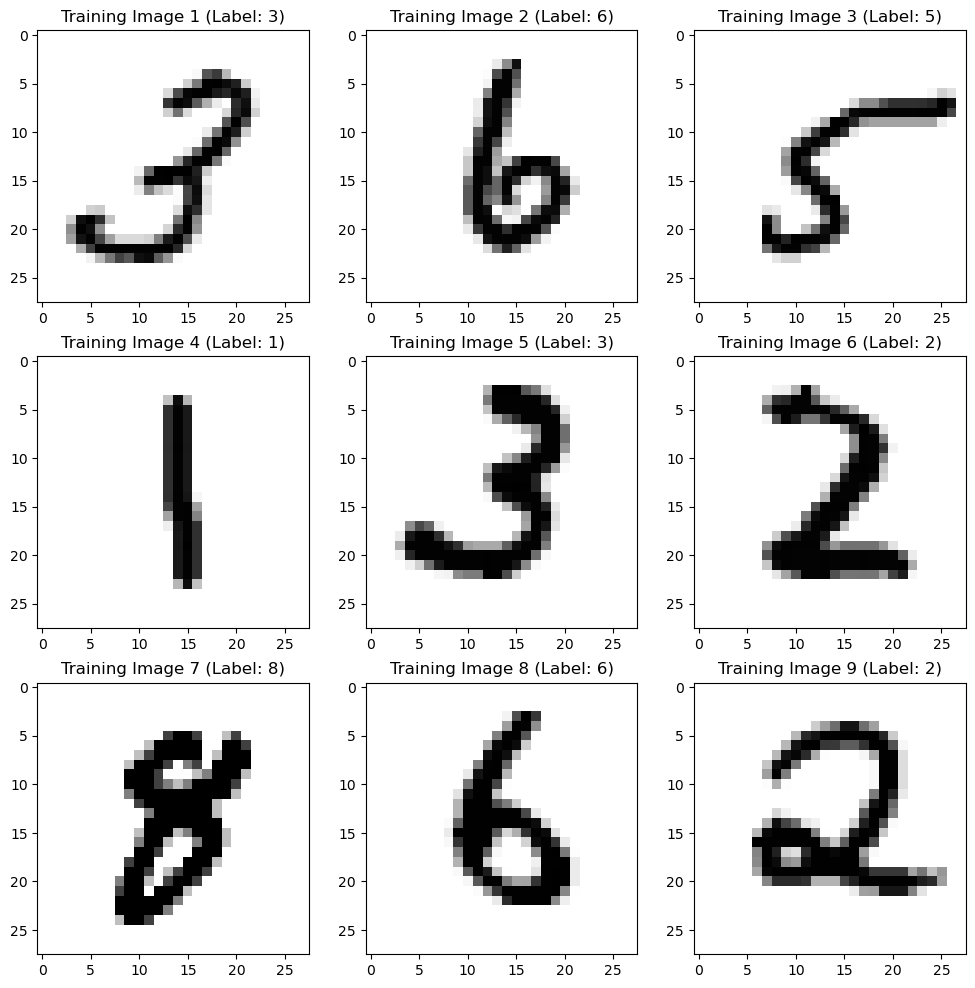

In [105]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-training_inputs[3*n+m].squeeze().clamp(0,1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Training Image {3*n+m+1} (Label: {training_labels[3*n+m]})")

plt.show()

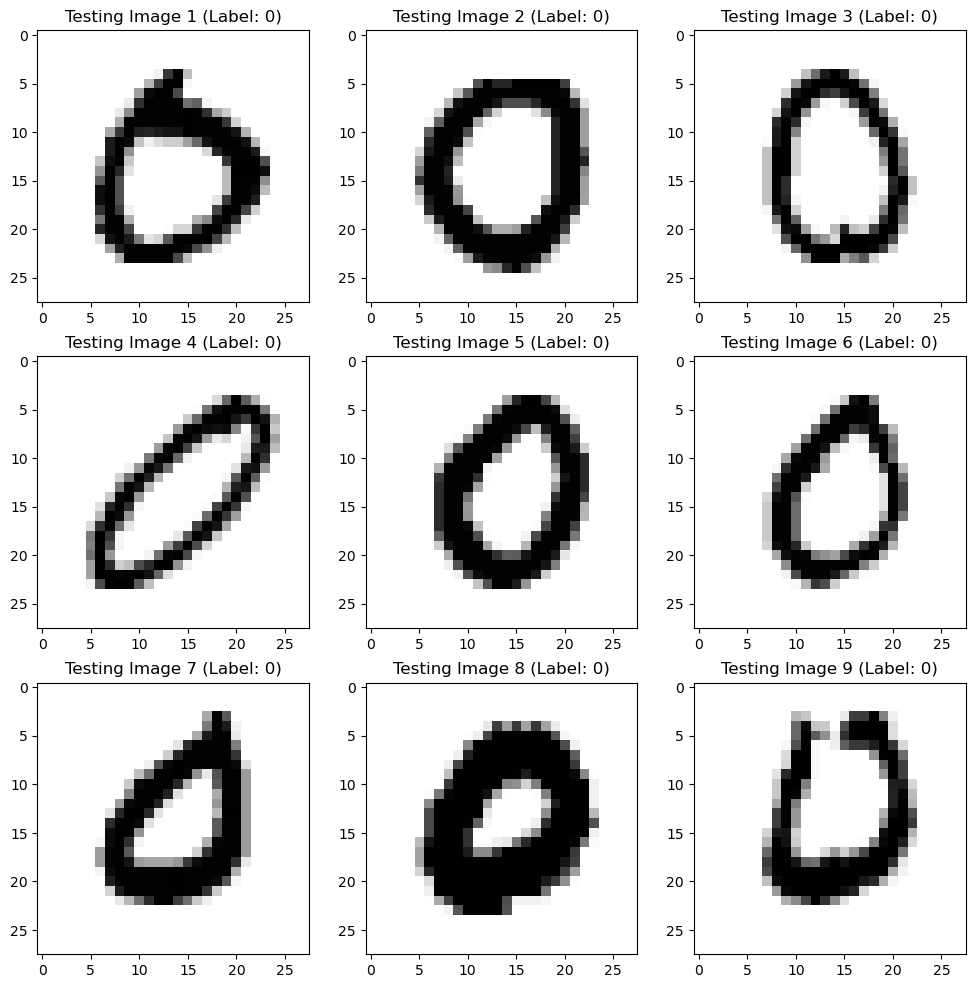

In [111]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-testing_inputs[3*n+m].squeeze().clamp(0, 1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Testing Image {3*n+m+1} (Label: {testing_labels[3*n+m]})")

plt.show()

In [112]:
total_num_training_images = 0
num_training_images = []

In [113]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 60000

Total number of training images: 60000


In [114]:
total_num_testing_images = 0
num_testing_images = []

In [115]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


### Permutations

In [116]:
num_perms = 5

In [117]:
perms_group_set = []

In [118]:
perms_group_set.append(torch.arange(28*28))
for i in range(num_perms-1):
    perms_group_set.append(torch.randperm(28*28))

In [119]:
len(perms_group_set), len(perms_group_set[0])

(5, 784)

### Defining NN Architecure

In [120]:
class NeuralNetwork(nn.Module):

    def __init__(self, input_size=28**2, hidden_size=128, output_size=10+1, T=5):
        super().__init__()

        self.flatten = nn.Flatten()
        self.relu = nn.ReLU()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.T = T

        self.ih = nn.Linear(self.input_size, self.hidden_size)
        self.hh = nn.Linear(self.hidden_size, self.hidden_size)
        self.ho = nn.Linear(self.hidden_size, self.output_size)

        nn.init.orthogonal_(self.hh.weight)
        
    def forward(self, inputs, perm):
        X = self.flatten(inputs)
        X = X[:, perm]
        
        batch_size = X.shape[0]

        h_traj = []
        logit_traj = []
        
        h = torch.zeros(batch_size, self.hidden_size, device=X.device)
        h_traj.append(h)

        logit = self.ho(h)
        logit_traj.append(logit)
        
        for t in range(self.T):
            
            h = self.relu(self.ih(X)+self.hh(h))
            h_traj.append(h)

            logit = self.ho(h)
            logit_traj.append(logit)

        h_traj = torch.stack(h_traj, dim=1)
        logit_traj = torch.stack(logit_traj, dim=1)
        
        initial_logits = logit_traj[:, 0, :]
        final_logits = logit_traj[:, self.T, :]
        
        return initial_logits, final_logits, h_traj, logit_traj

### Training 

In [170]:
num_epochs = 5

λ= 100
norm = 2

num_old_pca_components = 16

In [171]:
model = NeuralNetwork()

In [172]:
model_group_set = {}
cm_group_set = {}
pca_group_set = {}
scaler_group_set = {}
varexp_group_set = {}
kmeans_group_set = {}
loss_group_set = {}
connectivity_group_set = {}

In [173]:
penalty_function = None

fisher_running = None          # Online EWC: ONE accumulating Fisher
old_params     = None          # Online EWC: ONE anchor
γ_ewc          = 1.0           # decay on past Fisher (1.0 = no decay)

for i in range(num_perms):

    model_group_set[i], cm_group_set[i], pca_group_set[i], scaler_group_set[i], varexp_group_set[i], kmeans_group_set[i], loss_group_set[i], connectivity_group_set[i] = train_model(model, training_data_loader=training_groups[0], 
                                                                                                                                                                                    testing_data_loader=testing_groups, 
                                                                                                                                                                                    perm=perms_group_set[i], perms_set=perms_group_set,
                                                                                                                                                                                    num_epochs=num_epochs, 
                                                                                                                                                                                    penalty_function=penalty_function, λ=λ
                                                                                                                                                                                    )
    

    #####################################################################################
    ##### EWC PENALTY
    #####################################################################################
    fisher_task = compute_fisher(model, training_groups[0], perm=perms_group_set[i], num_samples=1000, empirical=True)
    if fisher_running is None:
        fisher_running = fisher_task
    else:
        fisher_running = {n: γ_ewc*fisher_running[n] + fisher_task[n] for n in fisher_task}
    old_params = snapshot_params(model)          # re-anchor to the CURRENT optimum
    penalty_function = partial(ewc_penalty, fisher=fisher_running, old_params=old_params)

    #####################################################################################
    ##### PCA DRIFT PENALTY
    #####################################################################################
    #pca_components = pca_group_set[i][-1][i].components_[:num_old_pca_components]
    #scaler = scaler_group_set[i][-1][i]
    #permutation = perms_group_set[i]
    #penalty_function = partial(pca_drift_penalty, old_pca_components = pca_components, old_scaler=scaler, norm=norm, permutation=permutation)

100%|██████████| 5/5 [01:21<00:00, 16.30s/it, Total Loss=384.3459]


In [174]:
for i in range(num_perms):

    print(model_group_set[i] is model)

False
False
False
False
False


### Confusion Matrix

In [202]:
cm_set = [[cm_group_set[i][j][0] for j in range(num_epochs)] for i in range(num_perms)]

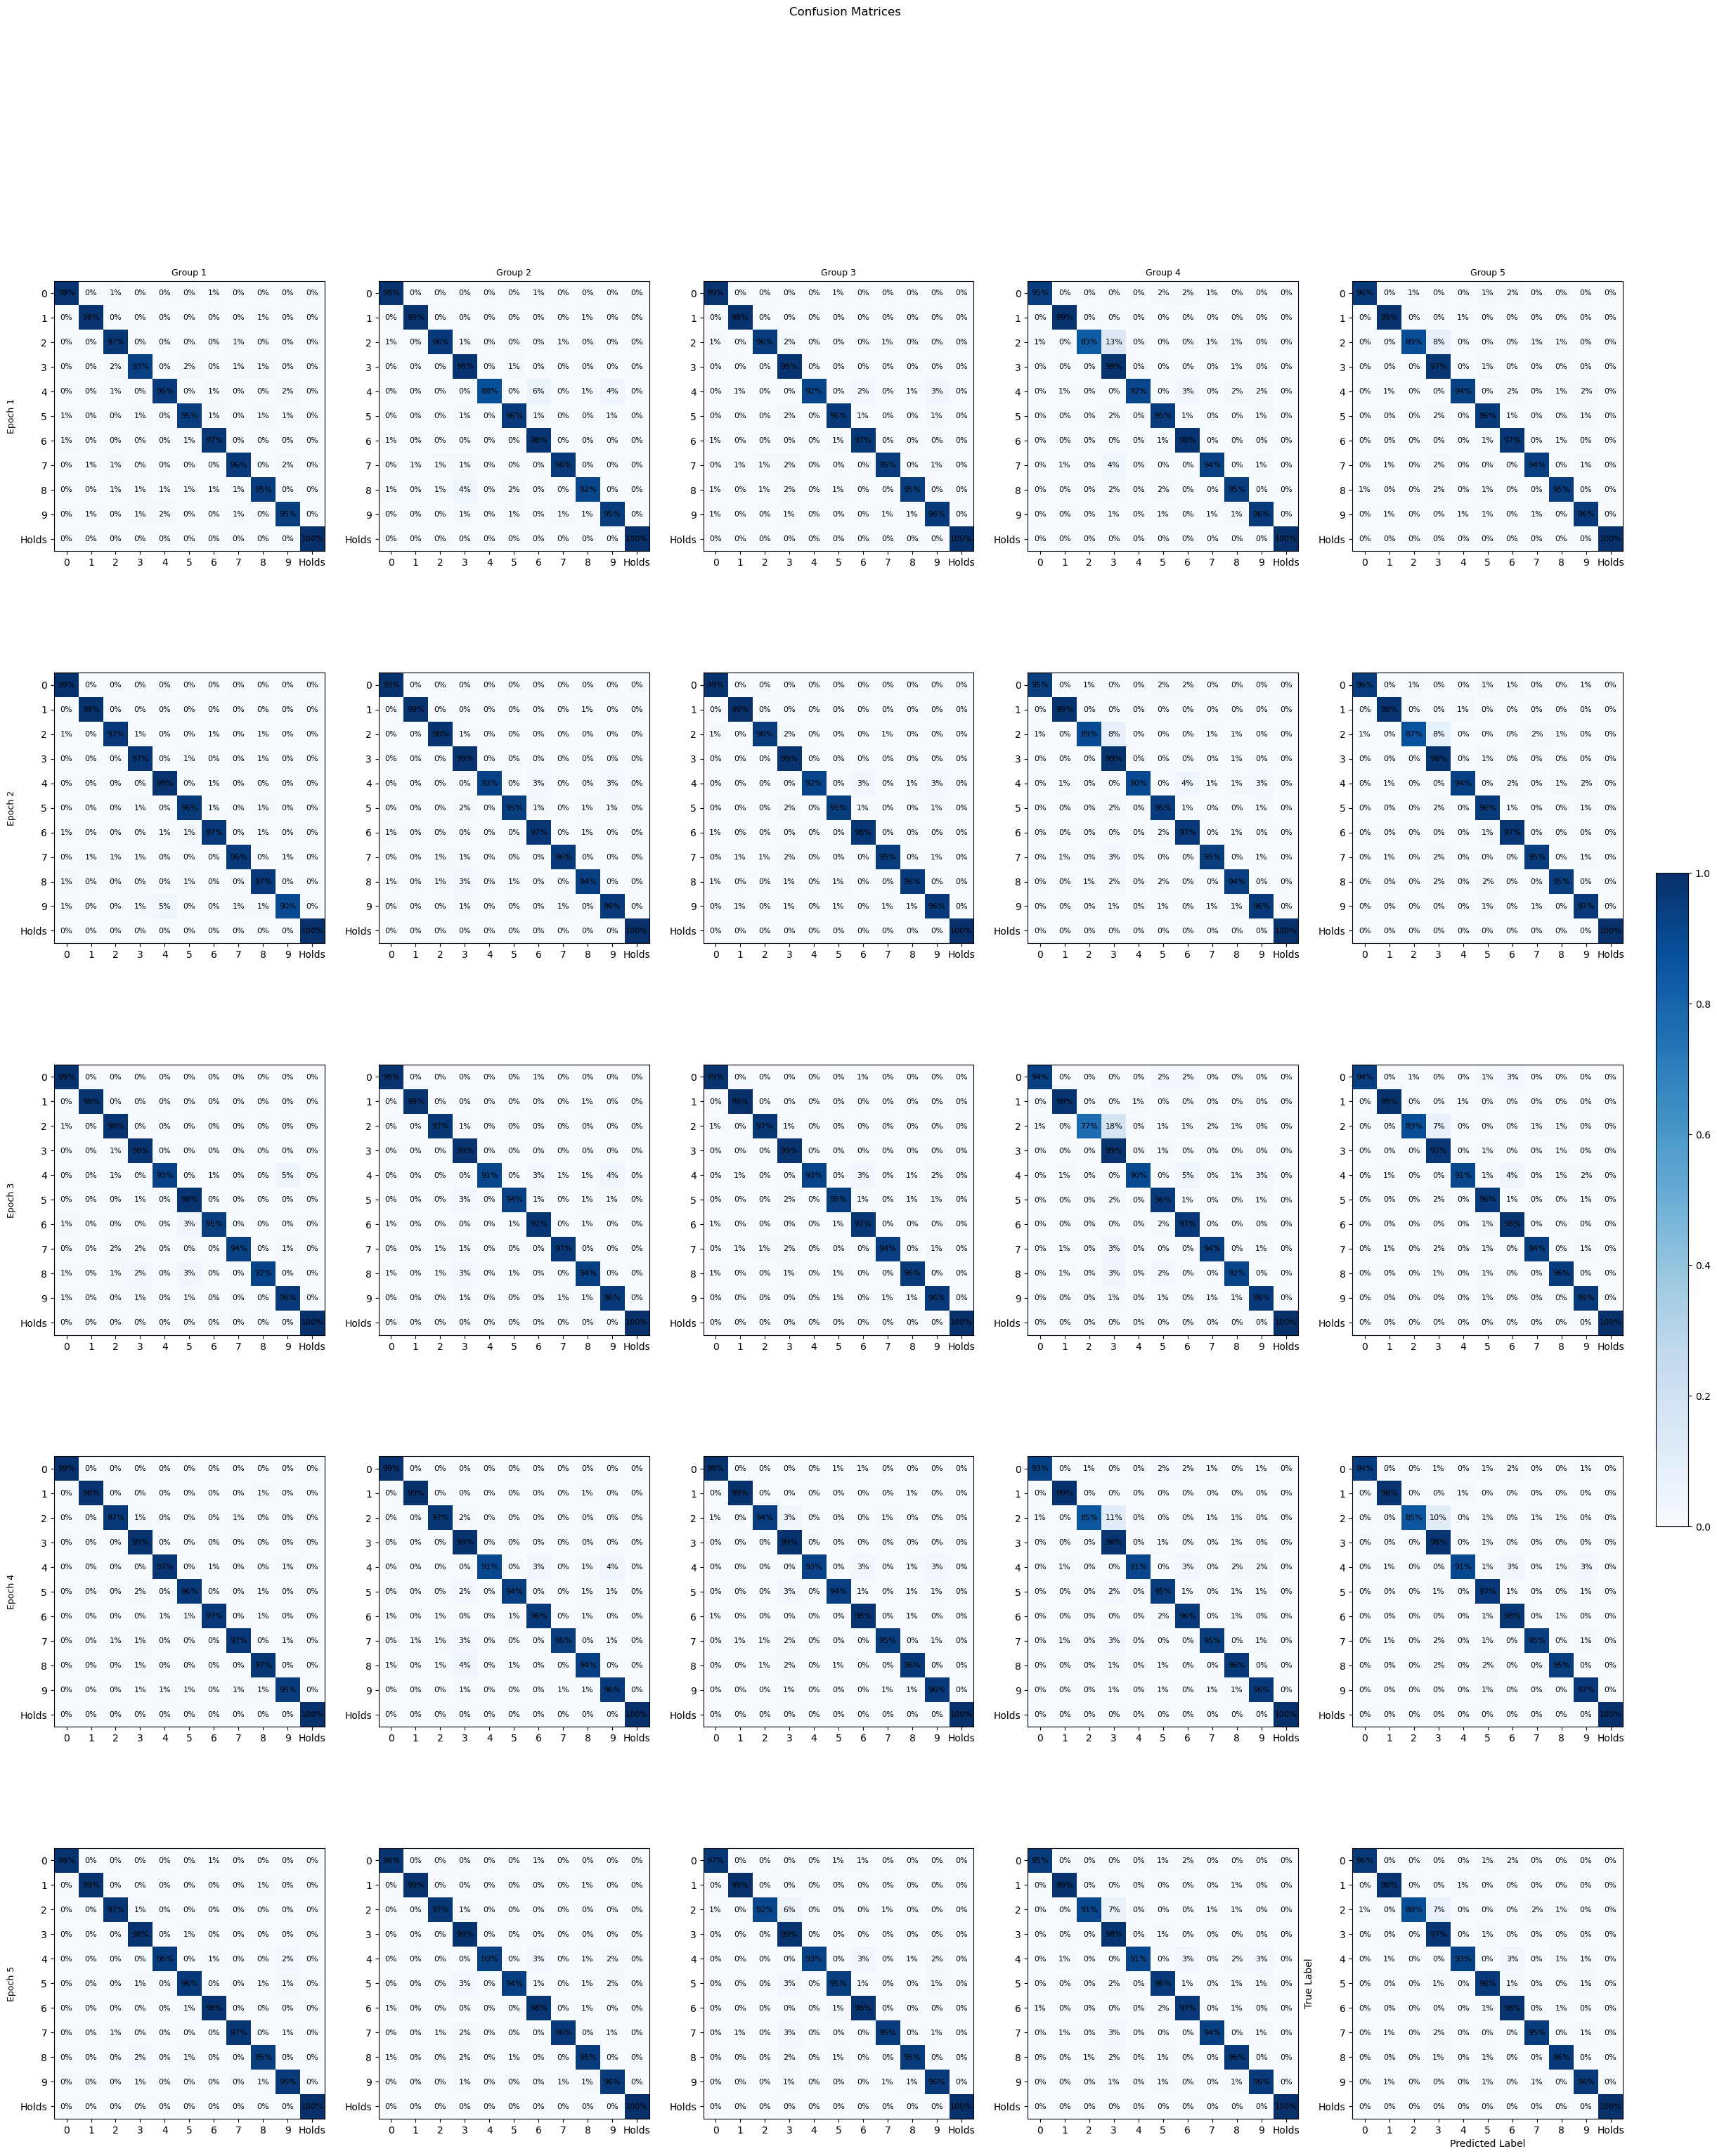

In [205]:
plot_cms(cm_set, normalize=True)

### Penultimate Layer PCA

In [177]:
μ_cgm, σ_cgm = monte_carlo_cgm(dim_subspace=1, dim_space=128, n_samples=100_000, seed=46)

In [178]:
μ_cgm, σ_cgm

(np.float64(0.07057831360862536), np.float64(0.0531917589178311))

In [179]:
pca_set = [[pca_group_set[i][j][0] for j in range(num_epochs)] for i in range(num_perms)]

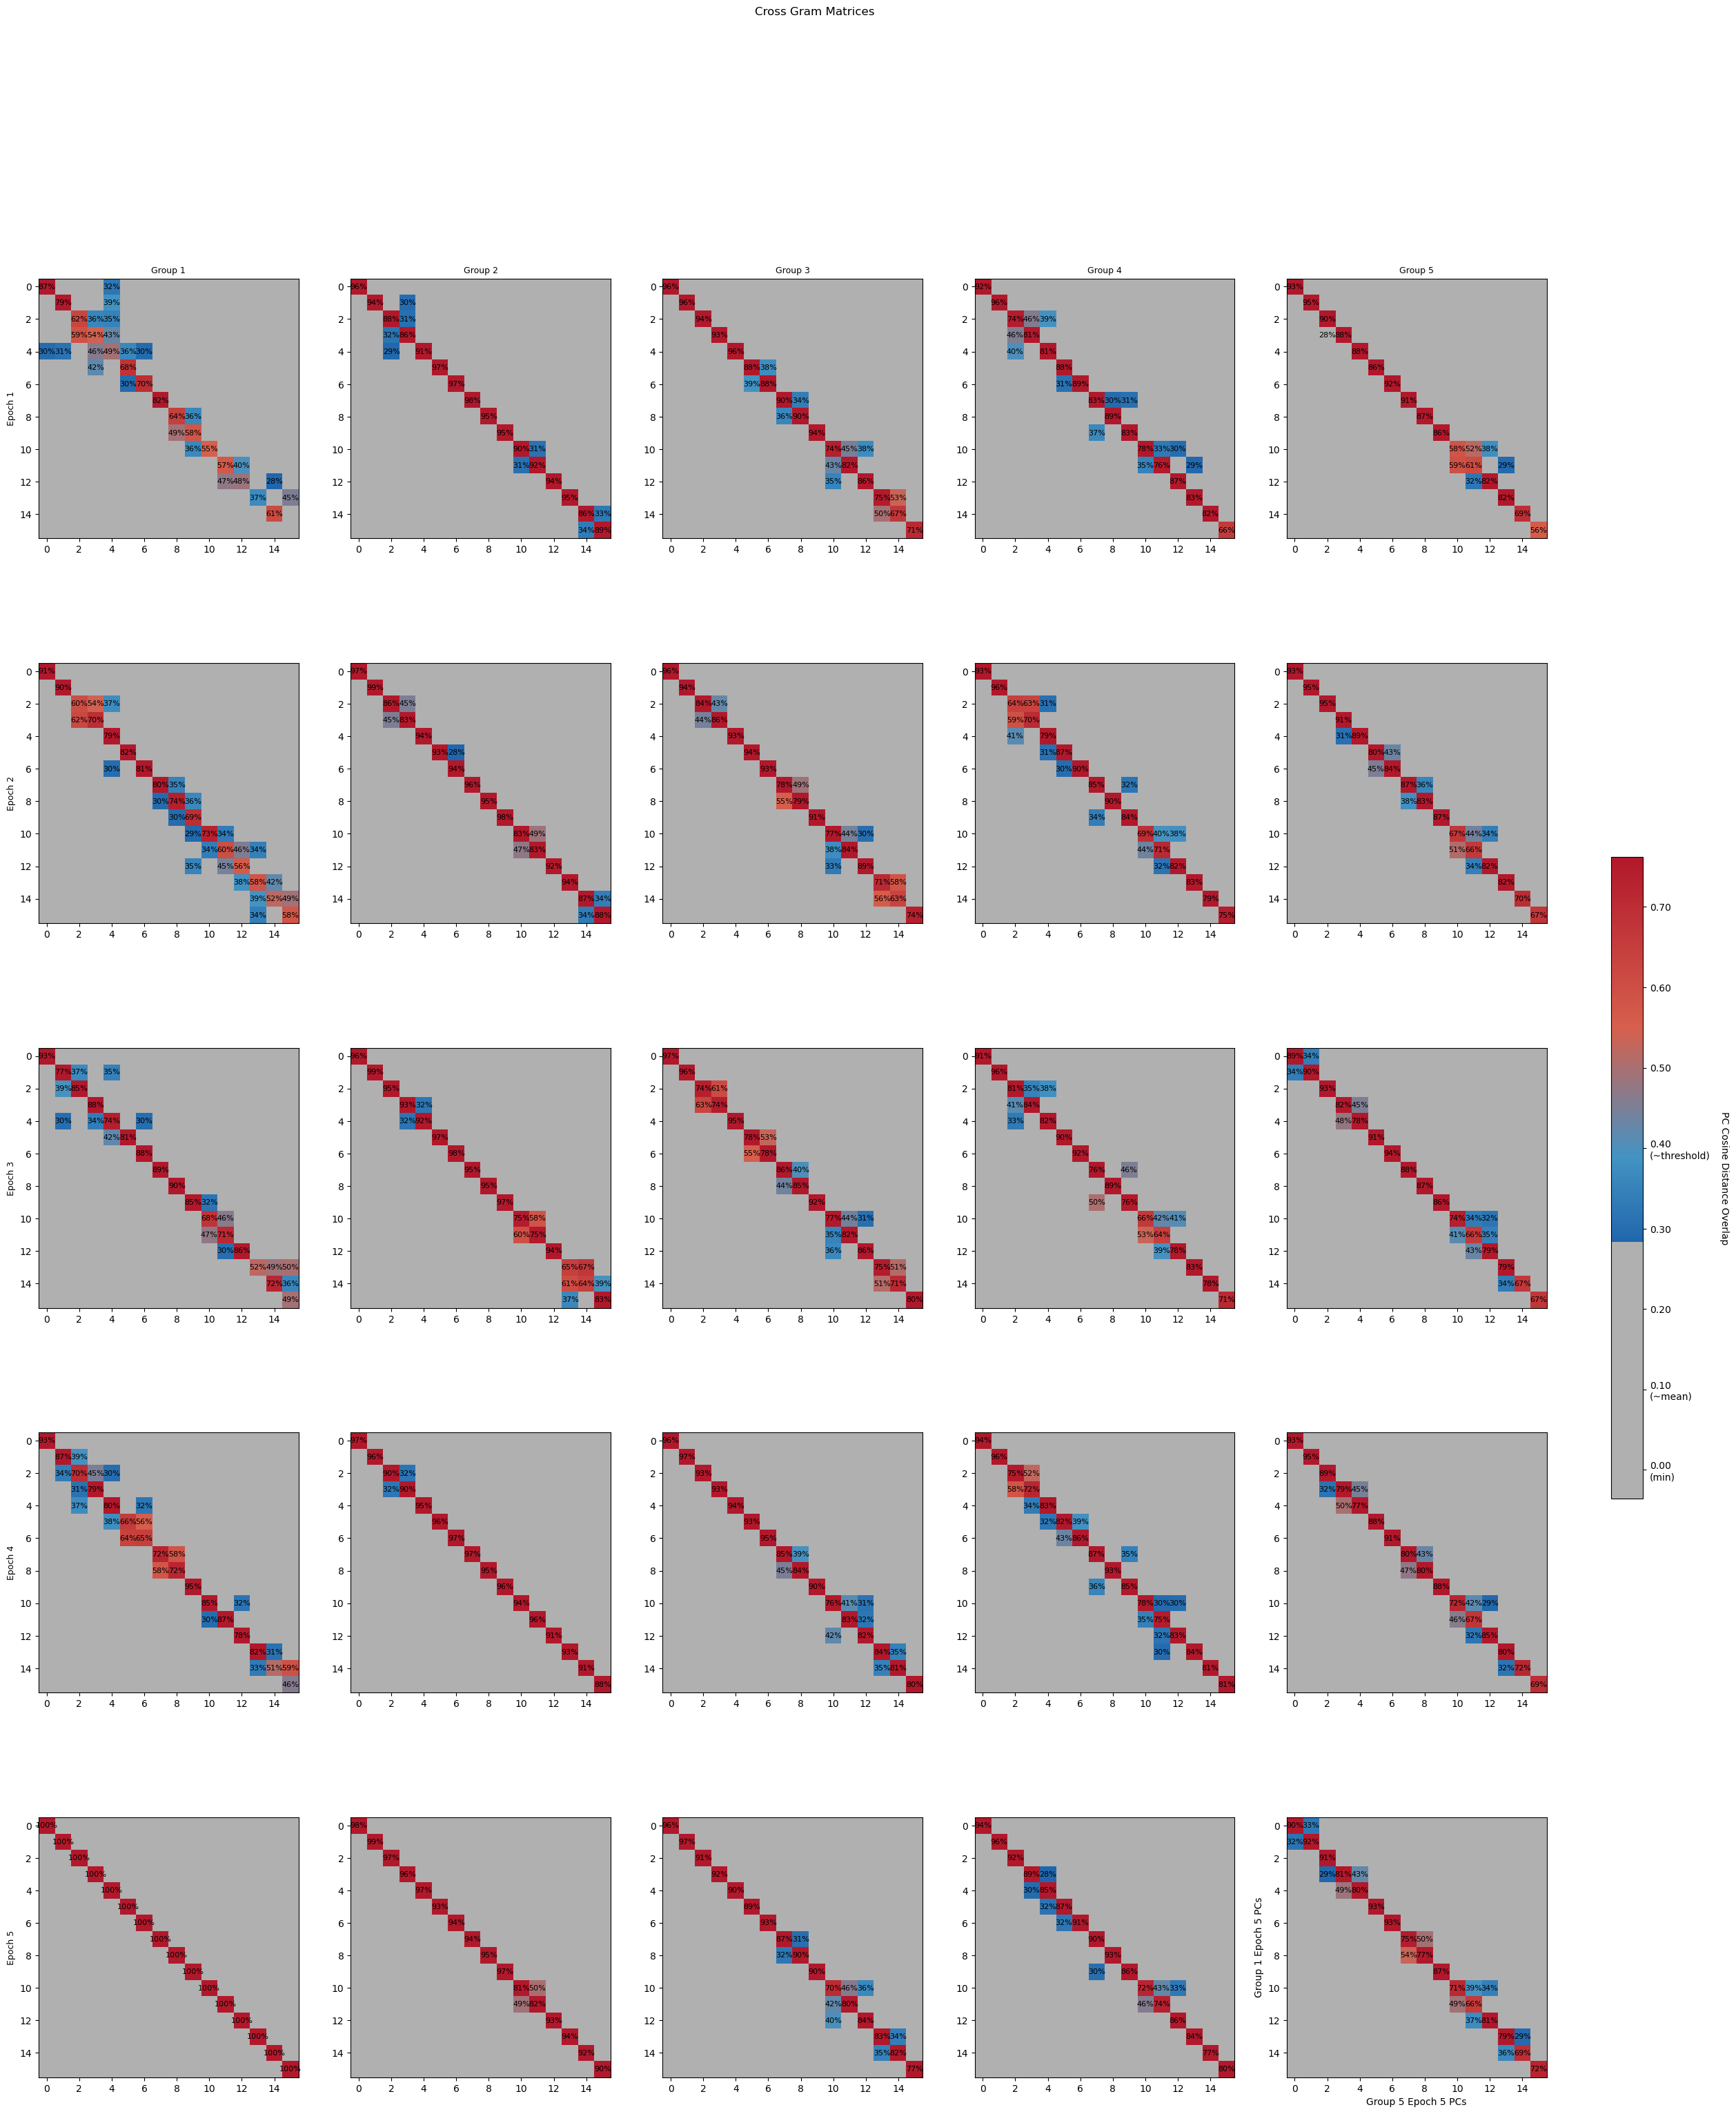

In [209]:
plot_cgms(pca_set, μ_cgm, σ_cgm, window=(0, num_old_pca_components), diagonalize=True)

### Variance Explained

In [181]:
varexp_set = [[varexp_group_set[i][j][0] for j in range(num_epochs)] for i in range(num_perms)]

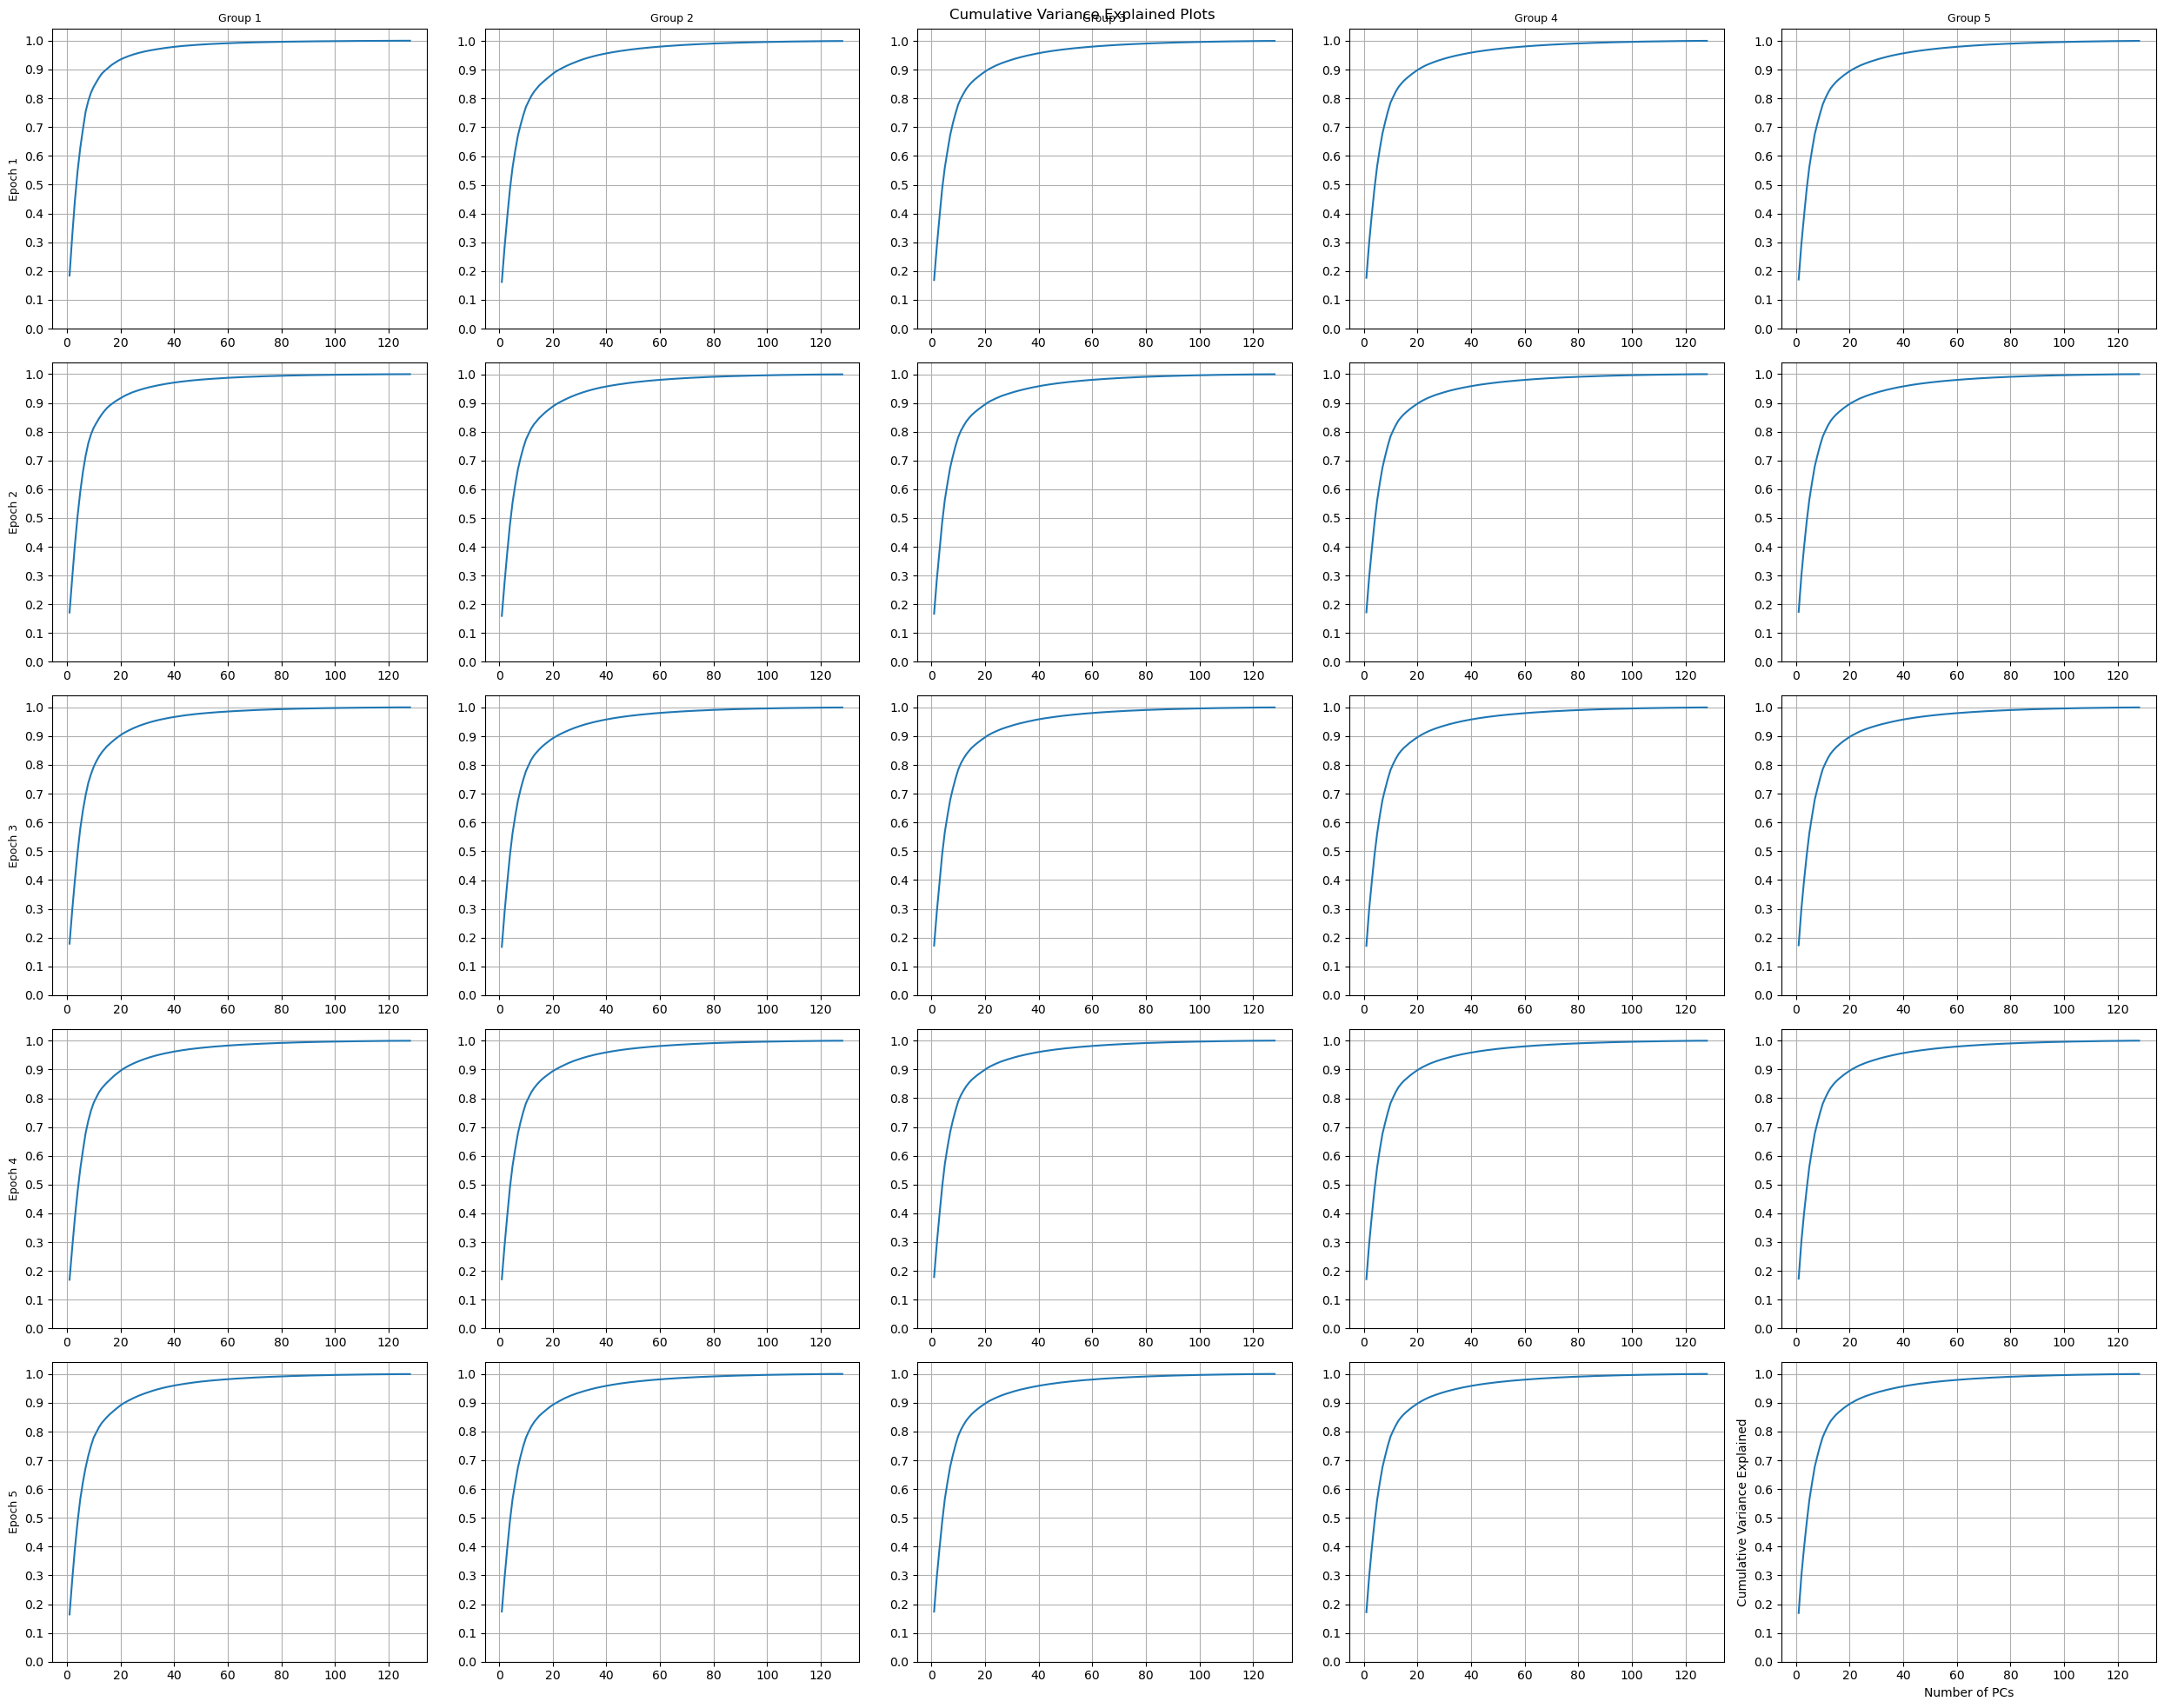

In [213]:
plot_varexp(varexp_set)

### k-Means of Hidden Representations

In [183]:
kmeans_set = [[kmeans_group_set[i][j][0] for j in range(num_epochs)] for i in range(num_perms)]

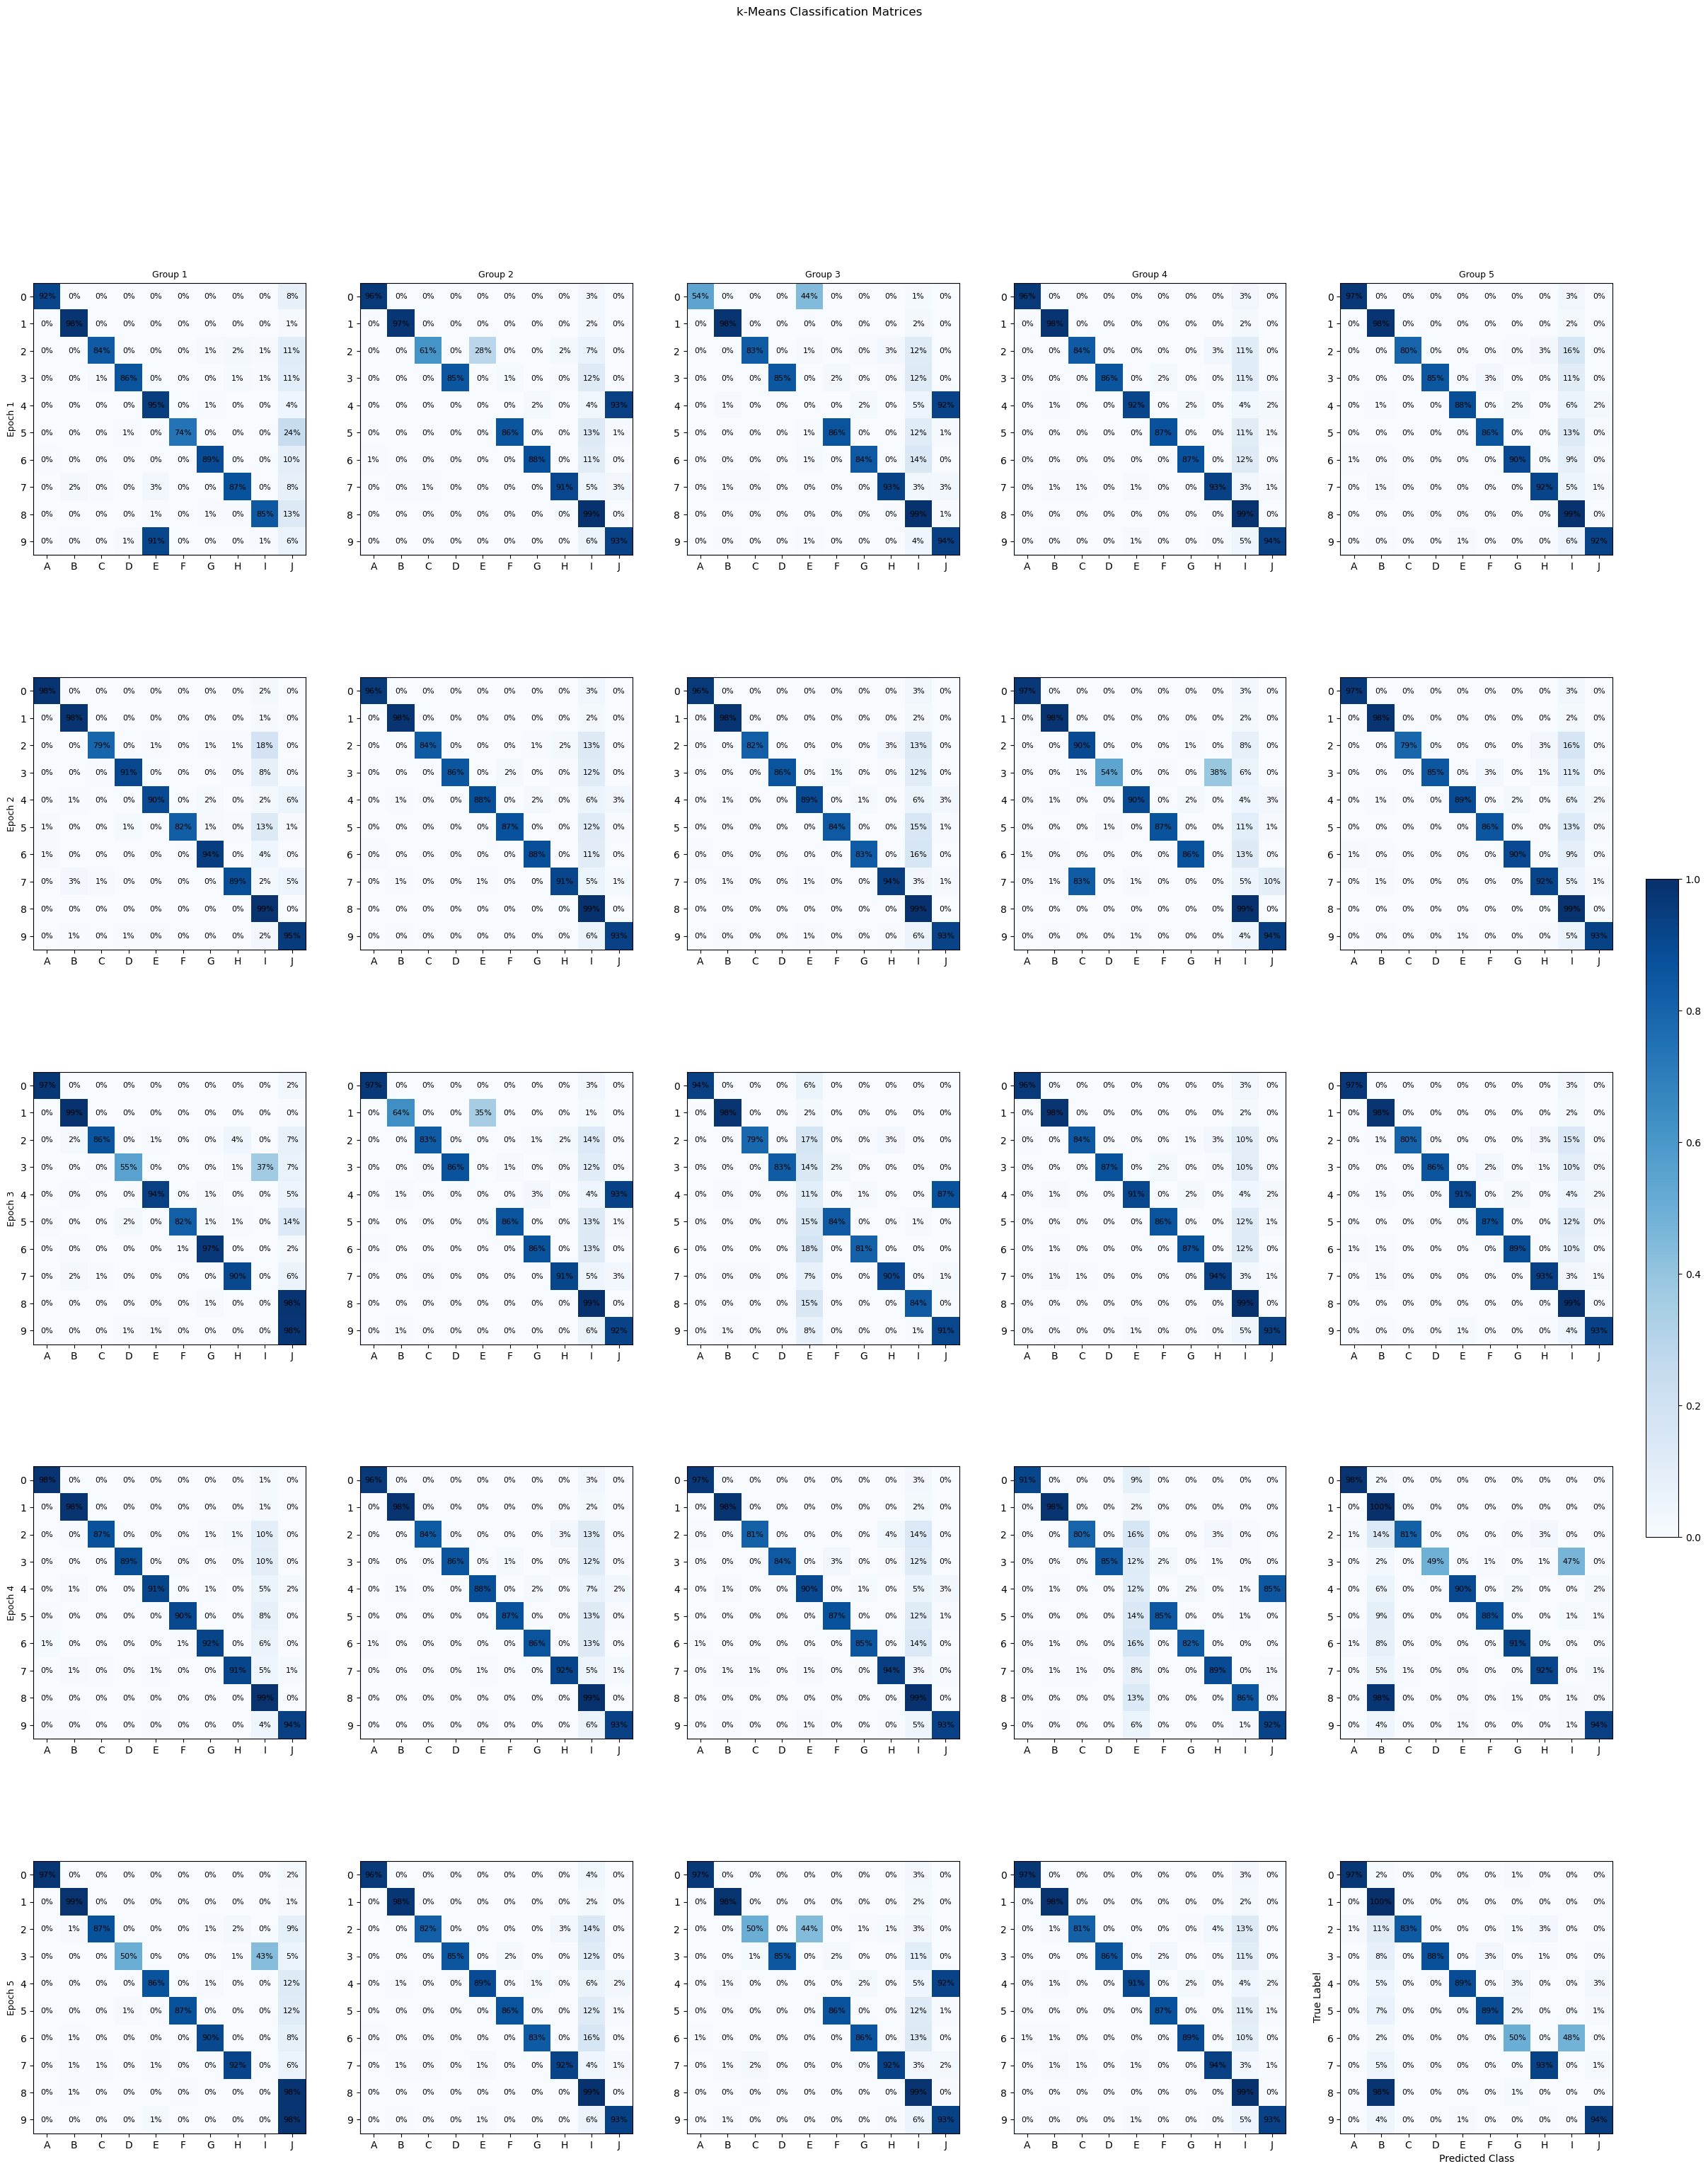

In [217]:
plot_kmeans(kmeans_set, diagonalize=True, normalize=True)

### Plotting Training Loss Curves

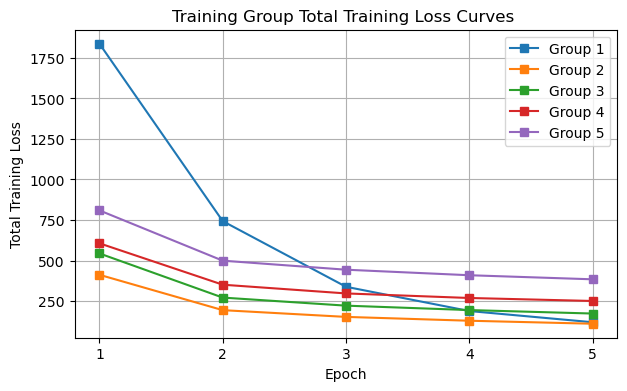

In [185]:
plot_loss(loss_group_set)

### Summary Plots

In [186]:
cm_summary     = get_cm_summary(cm_group_set)
kmeans_summary = get_kmeans_summary(kmeans_group_set)
pca_summary    = get_pca_summary(pca_group_set, window=(0, num_old_pca_components))

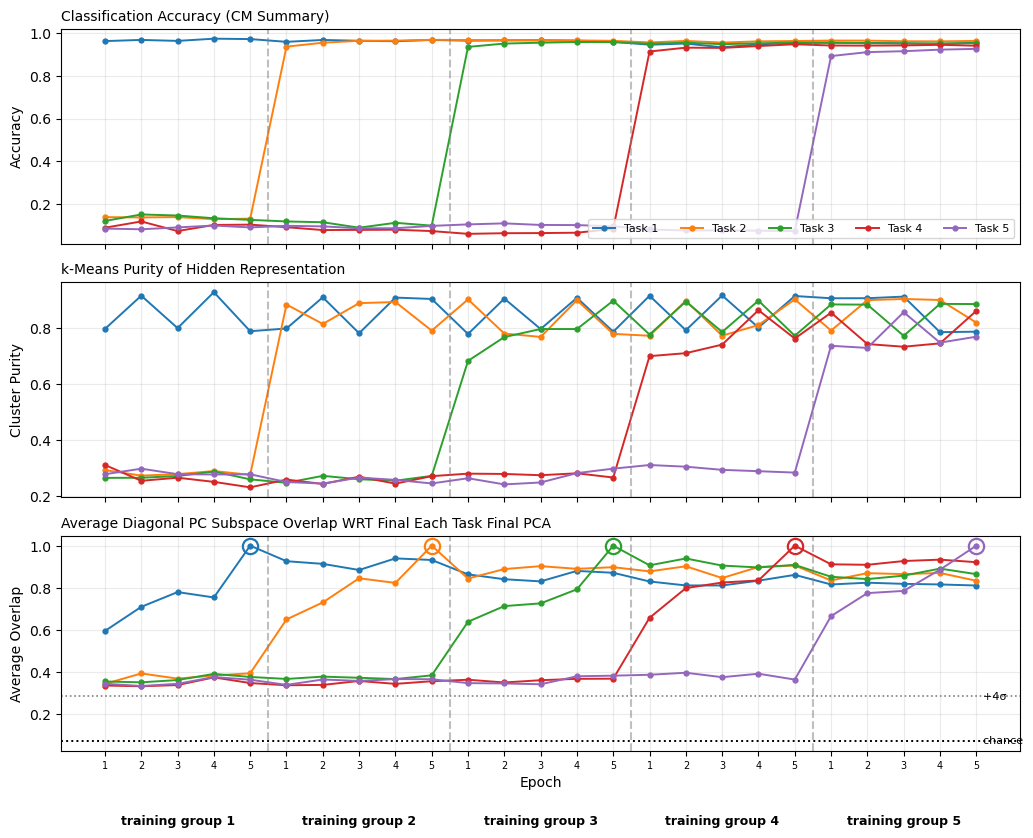

(<Figure size 1050x900 with 3 Axes>,
 array([<Axes: title={'left': 'Classification Accuracy (CM Summary)'}, ylabel='Accuracy'>,
        <Axes: title={'left': 'k-Means Purity of Hidden Representation'}, ylabel='Cluster Purity'>,
        <Axes: title={'left': 'Average Diagonal PC Subspace Overlap WRT Final Each Task Final PCA'}, xlabel='Epoch', ylabel='Average Overlap'>],
       dtype=object))

In [187]:
plot_summary(num_epochs=num_epochs,
                cm_summary=cm_summary,
                kmeans_summary=kmeans_summary,
                pca_summary=pca_summary,
                μ_cgm=μ_cgm, σ_cgm=σ_cgm)

### Connectivity Matrix

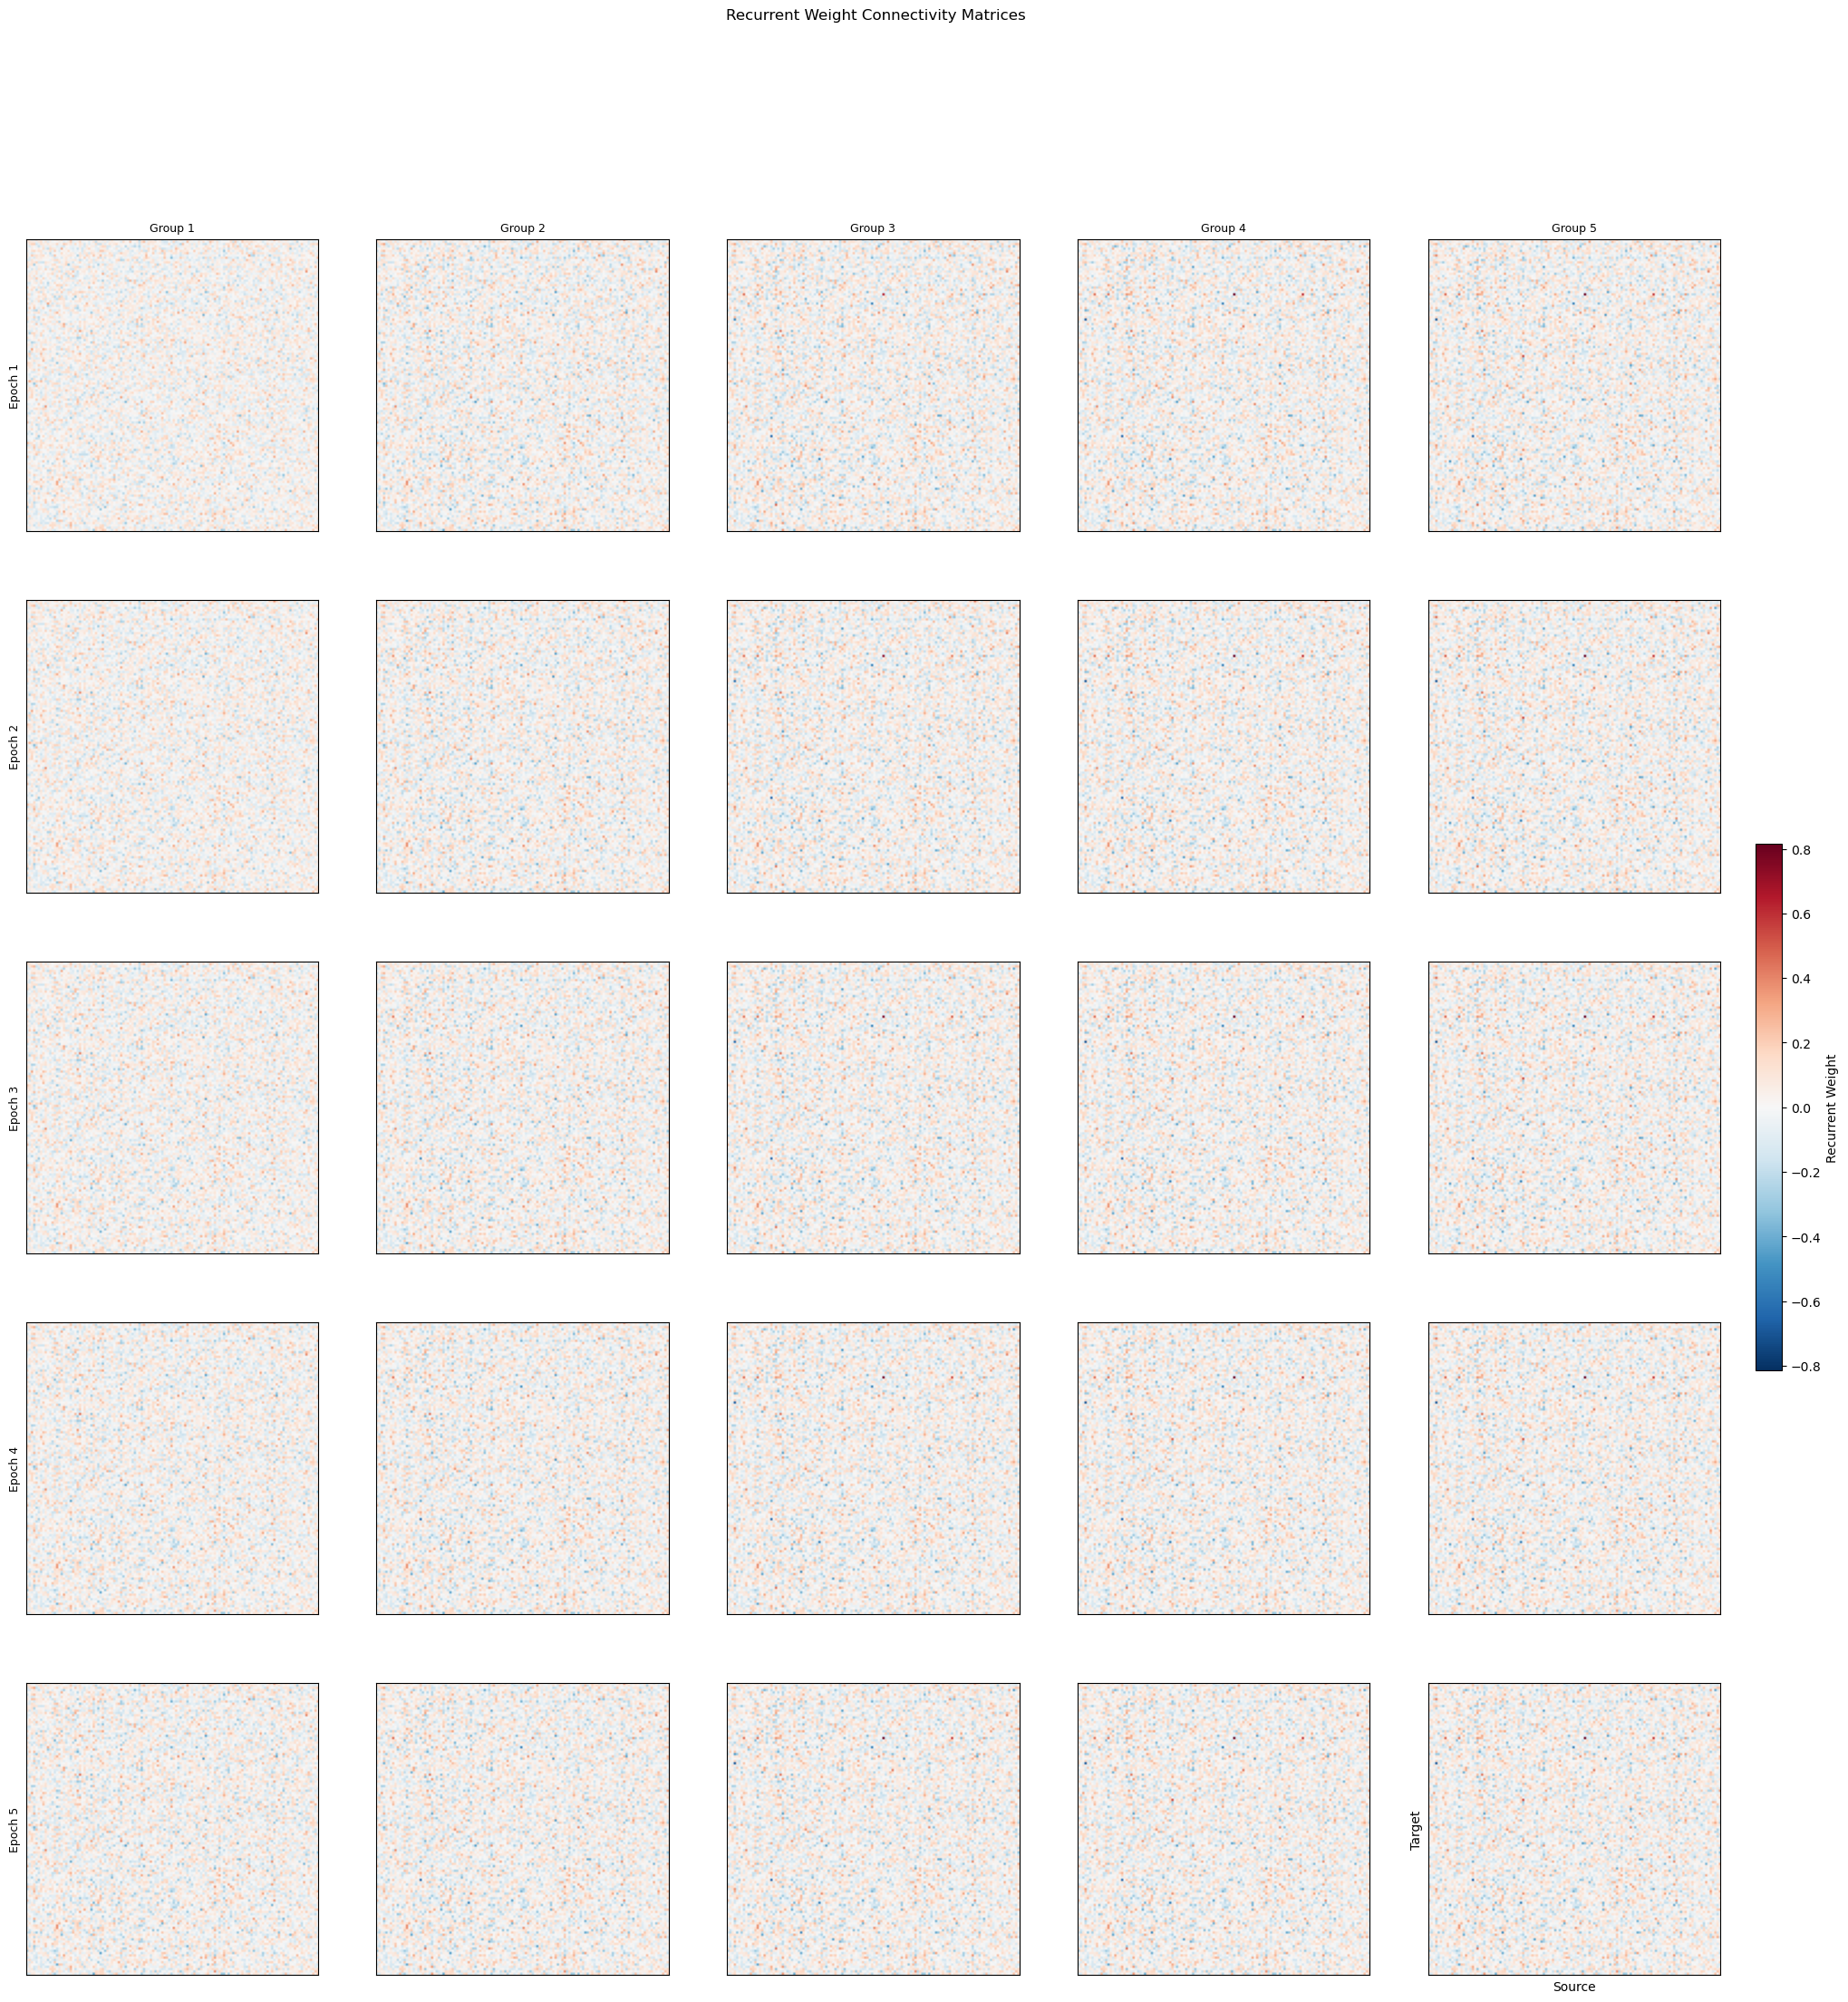

In [223]:
plot_connectivity(connectivity_group_set)

### Control Plot

In [ ]:
rng = np.random.default_rng(seed=SEED)
 
U = rng.standard_normal((64, 64)) 
V = rng.standard_normal((64, 64))        

U, _ = np.linalg.qr(U)                                                   
V, _ = np.linalg.qr(V)                                                   

cgm = np.abs(np.einsum("di, dj -> ij", U, V))        

c_cgm = (cgm - μ_cgm)/σ_cgm

In [ ]:
U.shape, V.shape

In [ ]:
cgm_cmap, cgm_norm = make_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4,
                                            mid1 = 6,
                                            mid2 = 9
                                        )
 
CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']

fig = plt.figure()

im = plt.imshow(c_cgm, cmap=cgm_cmap, norm=cgm_norm)
cbar = plt.colorbar(im, ticks=CGM_TICKS, fraction=0.05, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above baseline)", rotation=270, labelpad=20)

plt.title(f"Control Z-Scored Cross-Gram-Matrix")
plt.xlabel(f"Random Set A of 64 64-Dimensional Unit Vectors")
plt.ylabel(f"Random Set B of 64 64-Dimensional Unit Vectors")

plt.show()